In [1]:
import datajoint as dj


dj.config.load("dj_local_conf.json")

import numpy as np
from spyglass.position import PositionOutput
import spyglass.common as sgc
import pandas as pd

import sys
import os
sys.path.insert(0, os.path.abspath('../src'))
from behavior.forktrack_tables_dmr import ForkTrackParams, ForkTrackSelection, ForkTrackEvents


/home/dmrodriguez/miniforge3/envs/spyglass_py310_new/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-07-17 12:13:51,656][INFO]: DataJoint is configured from /home/dmrodriguez/mPFC-opto/notebooks/dj_local_conf.json
[2026-07-17 12:13:52,266][INFO]: DataJoint 0.14.9 connected to denissemorales@lmf-db.cin.ucsf.edu:3306


In [2]:
nwb_file_name = 'Caius20260623_.nwb'
epoch = 6

In [3]:
ForkTrackEvents() &{'nwb_file_name': nwb_file_name}

forktrack_params_name,nwb_file_name name of the NWB file,pos_merge_id,epoch,forktrack_results,validation_report,n_events,is_valid True if all validation checks passed,analysis_file_name name of the file,trial_object_id
default,Caius20260623_.nwb,3a3fb618-647b-f52b-fb62-72c19cc8a473,10,=BLOB=,=BLOB=,97,0,Caius20260623_XREZECQ3BW.nwb,59eac03d-6127-4558-9094-5fe898338feb
default,Caius20260623_.nwb,511a2056-0dff-cc2a-0d97-db879dec1952,2,=BLOB=,=BLOB=,51,1,Caius20260623_H4UXVUWUFB.nwb,136fbdb4-3767-454a-a521-6e6b87c3b567
default,Caius20260623_.nwb,595f4360-7eeb-794b-5004-ff086b5212bd,4,=BLOB=,=BLOB=,80,1,Caius20260623_529WRLXBMS.nwb,86c54e0b-9008-4649-9e48-9db5141084a6
default,Caius20260623_.nwb,5f1240f9-46c7-d61e-60e1-acc64e8c5e6b,6,=BLOB=,=BLOB=,104,1,Caius20260623_HX26LZY5LD.nwb,77ceccfe-9853-4f8f-b419-75fc48e20d18
default,Caius20260623_.nwb,664c41c2-1ba5-9ae1-a4ef-5e28d8b000ae,8,=BLOB=,=BLOB=,93,0,Caius20260623_BXHBYRF1RX.nwb,a6f53540-31d1-40e3-ae4d-42201c9ec852


In [4]:
forktrack_results = pd.DataFrame((ForkTrackEvents() &{'nwb_file_name': nwb_file_name, 'epoch': 6}).fetch('forktrack_results')[0])
forktrack_results

,time,epoch,well_name,prev_well,transition,trial_type,pump_triggered,pump_time,pump_delay,time_between_rewards,position_valid
0,1.782244e+09,6,Handle_poke,None,,Inbound,False,NaN,NaN,NaN,True
1,1.782244e+09,6,Left_poke,Handle_poke,Handle_poke→Left_poke,Outbound,True,1.782244e+09,0.006933,NaN,True
2,1.782244e+09,6,Handle_poke,Left_poke,Left_poke→Handle_poke,Inbound,True,1.782244e+09,0.007300,17.786336,True
3,1.782244e+09,6,Right_poke,Handle_poke,Handle_poke→Right_poke,Outbound,True,1.782244e+09,0.007100,13.229542,True
4,1.782244e+09,6,Handle_poke,Right_poke,Right_poke→Handle_poke,Inbound,True,1.782244e+09,0.007267,13.905585,True
...,...,...,...,...,...,...,...,...,...,...,...
99,1.782245e+09,6,Left_poke,Handle_poke,Handle_poke→Left_poke,Outbound,True,1.782245e+09,0.007133,10.509606,True
100,1.782245e+09,6,Handle_poke,Left_poke,Left_poke→Handle_poke,Inbound,True,1.782245e+09,0.007433,13.742649,True
101,1.782245e+09,6,Right_poke,Handle_poke,Handle_poke→Right_poke,Outbound,True,1.782245e+09,0.007300,10.697542,True
102,1.782245e+09,6,Handle_poke,Right_poke,Right_poke→Handle_poke,Inbound,True,1.782245e+09,0.007500,8.118708,True


In [5]:
import pandas as pd

def normalize_well(name):
    if pd.isna(name):
        return None
    name = str(name).replace("_poke", "").lower()
    if name in {"left", "right", "center", "handle"}:
        return name
    return name

def infer_trajectory(row):
    prev_well = normalize_well(row["prev_well"])
    well = normalize_well(row["well_name"])
    trial_type = str(row["trial_type"]).lower() if not pd.isna(row["trial_type"]) else ""

    # center-out
    if prev_well == "center" and well == "left":
        return "center_to_left"
    if prev_well == "center" and well == "right":
        return "center_to_right"
    if prev_well == "center" and well == "handle":
        return "center_to_handle"

    # side-in
    if prev_well == "left" and well == "center":
        return "left_to_center"
    if prev_well == "right" and well == "center":
        return "right_to_center"
    if prev_well == "left" and well == "handle":
        return "left_to_handle"
    if prev_well == "right" and well == "handle":
        return "right_to_handle"


    # if the row is side-to-side, keep it separate or ignore it
    if prev_well == "left" and well == "right":
        return "left_to_right"
    if prev_well == "right" and well == "left":
        return "right_to_left"

    if prev_well == "handle" and well == "right":
        return "handle_to_right"
    if prev_well == "handle" and well == "left":
        return "handle_to_left"
    if prev_well == "handle" and well == "center":
        return "handle_to_center"


    return pd.NA

In [6]:
forktrack_results["trajectory"] = forktrack_results.apply(infer_trajectory, axis=1)


In [7]:
forktrack_results

,time,epoch,well_name,prev_well,transition,trial_type,pump_triggered,pump_time,pump_delay,time_between_rewards,position_valid,trajectory
0,1.782244e+09,6,Handle_poke,None,,Inbound,False,NaN,NaN,NaN,True,<NA>
1,1.782244e+09,6,Left_poke,Handle_poke,Handle_poke→Left_poke,Outbound,True,1.782244e+09,0.006933,NaN,True,handle_to_left
2,1.782244e+09,6,Handle_poke,Left_poke,Left_poke→Handle_poke,Inbound,True,1.782244e+09,0.007300,17.786336,True,left_to_handle
3,1.782244e+09,6,Right_poke,Handle_poke,Handle_poke→Right_poke,Outbound,True,1.782244e+09,0.007100,13.229542,True,handle_to_right
4,1.782244e+09,6,Handle_poke,Right_poke,Right_poke→Handle_poke,Inbound,True,1.782244e+09,0.007267,13.905585,True,right_to_handle
...,...,...,...,...,...,...,...,...,...,...,...,...
99,1.782245e+09,6,Left_poke,Handle_poke,Handle_poke→Left_poke,Outbound,True,1.782245e+09,0.007133,10.509606,True,handle_to_left
100,1.782245e+09,6,Handle_poke,Left_poke,Left_poke→Handle_poke,Inbound,True,1.782245e+09,0.007433,13.742649,True,left_to_handle
101,1.782245e+09,6,Right_poke,Handle_poke,Handle_poke→Right_poke,Outbound,True,1.782245e+09,0.007300,10.697542,True,handle_to_right
102,1.782245e+09,6,Handle_poke,Right_poke,Right_poke→Handle_poke,Inbound,True,1.782245e+09,0.007500,8.118708,True,right_to_handle


In [8]:
pos_key = {
    "nwb_file_name": nwb_file_name,
    "epoch": 6,
}

merge_id = (PositionOutput.DLCPosV1() & pos_key).fetch1("merge_id")
position_info = (PositionOutput & {"merge_id": merge_id}).fetch1_dataframe()
position_info

/home/dmrodriguez/miniforge3/envs/spyglass_py310_new/lib/python3.10/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
ndx-pose - cached version: 0.2.0, loaded version: 0.3.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)
/home/dmrodriguez/miniforge3/envs/spyglass_py310_new/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/MarketTech LuxX+ Red/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/dmrodriguez/miniforge3/envs/spyglass_py310_new/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/dev

,video_frame_ind,position_x,position_y,orientation,velocity_x,velocity_y,speed
time,,,,,,,
1.782244e+09,0.0,126.162272,162.495945,0.829629,0.666047,-0.100401,0.673572
1.782244e+09,1.0,126.287565,162.473067,0.806860,0.663538,-0.052078,0.665578
1.782244e+09,2.0,126.238163,162.479021,0.814959,0.580651,0.053555,0.583116
1.782244e+09,3.0,126.257445,162.447760,0.815677,0.462950,0.227380,0.515776
1.782244e+09,4.0,126.301047,162.496092,0.842347,0.369390,0.480139,0.605791
...,...,...,...,...,...,...,...
1.782245e+09,29674.0,77.077215,13.640619,-2.407879,0.351017,-0.664289,0.751327
1.782245e+09,29675.0,77.078254,13.639413,-2.406693,0.609268,-0.696734,0.925552
1.782245e+09,29676.0,77.513895,13.592731,-2.372905,0.588759,-0.633492,0.864841


In [9]:
linear_key = {
    "pos_merge_id": merge_id,
    "linearization_param_name": "default",
}

from spyglass.linearization.merge import LinearizedPositionOutput

linear_merge_key = LinearizedPositionOutput.merge_restrict(linear_key).fetch1(
    "KEY"
)
linear_position_df = (
    LinearizedPositionOutput & linear_merge_key
).fetch1_dataframe()
linear_position_df

/home/dmrodriguez/miniforge3/envs/spyglass_py310_new/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/MarketTech LuxX+ Red/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/dmrodriguez/miniforge3/envs/spyglass_py310_new/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/Optical fiber 1/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/dmrodriguez/miniforge3/envs/spyglass_py310_new/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/Optical fiber 2/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/dmrodriguez/miniforge3/envs/spyglass_py310_new/lib/python3.10/sit

,linear_position,track_segment_id,projected_x_position,projected_y_position
time,,,,
1.782244e+09,110.261086,4,129.197878,160.269834
1.782244e+09,110.205442,4,129.230784,160.314706
1.782244e+09,110.229855,4,129.216347,160.295019
1.782244e+09,110.243660,4,129.208183,160.283886
1.782244e+09,110.178901,4,129.246479,160.336108
...,...,...,...,...
1.782245e+09,0.000000,0,74.930020,17.850164
1.782245e+09,0.000000,0,74.930020,17.850164
1.782245e+09,0.000000,0,74.930020,17.850164


In [10]:
linear_position_df = pd.merge_asof(
    linear_position_df,
    forktrack_results[["time", "trajectory"]].sort_values("time"),
    on="time",
    direction="backward"
)

In [11]:
linear_position_df["trajectory"].value_counts(dropna=False)

trajectory
left_to_handle     8335
handle_to_left     7813
right_to_handle    6873
handle_to_right    5968
NaN                 547
<NA>                143
Name: count, dtype: int64

In [12]:
import matplotlib.pyplot as plt
from neurospatial.behavior.navigation import path_progress
import numpy as np
import spyglass.linearization.v1 as sgpl
from neurospatial import Environment
import networkx as nx
import numpy as np

track_graph_name = "dmr fork caius"

track_graph = (sgpl.TrackGraph & {"track_graph_name": track_graph_name }).get_networkx_track_graph()
edge_order = (sgpl.TrackGraph & {"track_graph_name": track_graph_name }).fetch1("linear_edge_order")
edge_spacing = (sgpl.TrackGraph & {"track_graph_name": track_graph_name }).fetch1("linear_edge_spacing")
edge_order = [(int(a), int(b)) for a, b in edge_order]

env = Environment.from_graph(
    track_graph,
    edge_order=edge_order,
    edge_spacing=edge_spacing,
    bin_size=2.5,
    name=track_graph_name ,
)

# Define goal positions in 2D (x, y) for each arm end
goal_positions_2d = {
    "left_arm":  np.array([[75, 18]]),
    "right_arm": np.array([[15.6, 55]]),
    "center":    np.array([[49, 34]]),
    "handle":  np.array([[129.35227477, 160.48037469]]),
}

# Convert 2D positions to bin indices
start_bin = env.bin_at(np.array([[129, 160]]))[0]  # center/home
left_bin  = env.bin_at(np.array([[75, 18]]))[0]
right_bin = env.bin_at(np.array([[15, 55]]))[0]
center_bin = env.bin_at(np.array([[49, 34]]))[0]

print(start_bin, left_bin, right_bin, center_bin)  # verify these are valid (>= 0)

_orig_to_scipy_sparse_array = nx.to_scipy_sparse_array

def _patched_to_scipy_sparse_array(G, weight=None, format="csr"):
    A = _orig_to_scipy_sparse_array(G, weight=weight, format=format)
    A.indices = A.indices.astype(np.int32)
    A.indptr = A.indptr.astype(np.int32)
    return A

nx.to_scipy_sparse_array = _patched_to_scipy_sparse_array

44 0 117 118


In [19]:
position_bins = env.bin_at(
    position_info[["position_x", "position_y"]].values  # shape (n, 2)
).astype(int)



trajectory_goals = {
    "handle_to_left":  (left_bin, start_bin),
    "left_to_handle":  (start_bin,  left_bin),
    "handle_to_right": (right_bin, start_bin),
    "right_to_handle": (start_bin, right_bin),
    "left_to_right":   (left_bin,  right_bin),
    "right_to_left":   (right_bin, left_bin),
}

node_lin = env.to_linear(np.array([[168.1, 128], [196.9, 111.8], [139.3, 144.1]]))


xy_cols = ["position_x", "position_y"]
finite_mask = np.isfinite(position_info[xy_cols].values).all(axis=1)
print(f"Dropping {(~finite_mask).sum()} of {len(position_info)} rows")

position_info = position_info.loc[finite_mask].reset_index(drop=True)
linear_position_df = linear_position_df.loc[finite_mask].reset_index(drop=True)

position_bins = env.bin_at(position_info[xy_cols].values).astype(int)

start_bins = np.full(len(position_bins), -1)
goal_bins  = np.full(len(position_bins), -1)

for traj, (s, g) in trajectory_goals.items():
    mask = (linear_position_df["trajectory"] == traj).values
    start_bins[mask] = s
    goal_bins[mask]  = g

progress = path_progress(
    position_bins,
    env,
    start_bins=start_bins,
    goal_bins=goal_bins,
)
linear_position_df["trajectory_progress"] = progress

Dropping 0 of 29641 rows


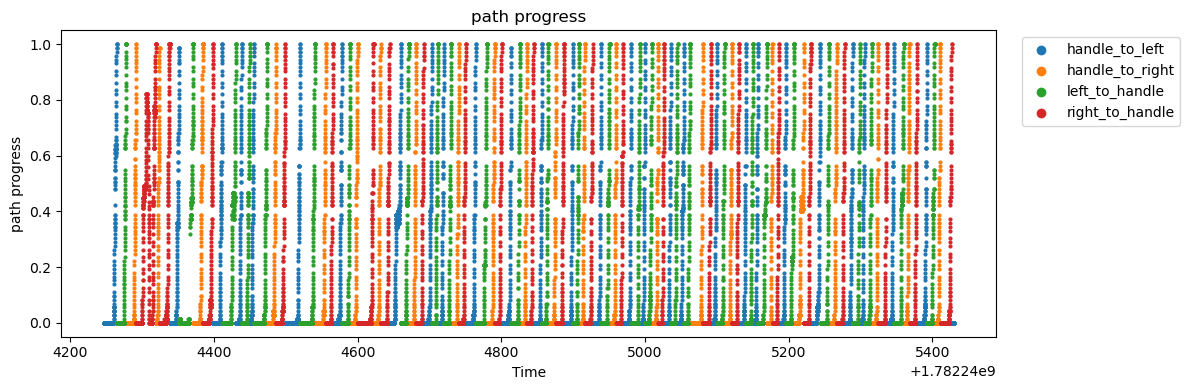

In [20]:
plt.figure(figsize=(12, 4))
for traj, g in linear_position_df.dropna(subset=["trajectory_progress"]).groupby("trajectory"):
    plt.scatter(g["time"], g["trajectory_progress"], s=4, label=traj)

plt.xlabel("Time")
plt.ylabel("path progress")
plt.title("path progress")
plt.ylim(-0.05, 1.05)
plt.legend(markerscale=3, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [21]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

group_key = {
    "nwb_file_name": nwb_file_name,
    "sorted_spikes_group_name": "mPFC_opto",
}
SortedSpikesGroup & group_key

nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name
Caius20260623_.nwb,exclude_all_other,mPFC_opto


In [16]:
group_key = (SortedSpikesGroup & group_key).fetch1("KEY")
SortedSpikesGroup().fetch_spike_data(group_key)

/home/dmrodriguez/miniforge3/envs/spyglass_py310/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/dmrodriguez/miniforge3/envs/spyglass_py310/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1408: UserWarning: The model attribute of the Device "MarketTech LuxX+ Red" was detected as a non-DeviceModel objec

[array([1.76539079e+09, 1.76539079e+09, 1.76539079e+09, ...,
        1.76541239e+09, 1.76541239e+09, 1.76541239e+09]),
 array([1.76539079e+09, 1.76539079e+09, 1.76539079e+09, ...,
        1.76541239e+09, 1.76541239e+09, 1.76541239e+09]),
 array([1.76539079e+09, 1.76539080e+09, 1.76539080e+09, ...,
        1.76541239e+09, 1.76541239e+09, 1.76541239e+09]),
 array([1.76539084e+09, 1.76539085e+09, 1.76539086e+09, ...,
        1.76541231e+09, 1.76541232e+09, 1.76541233e+09]),
 array([1.76539189e+09, 1.76539199e+09, 1.76539200e+09, ...,
        1.76541168e+09, 1.76541168e+09, 1.76541168e+09]),
 array([1.76539229e+09, 1.76539231e+09, 1.76539231e+09, 1.76539231e+09,
        1.76539239e+09, 1.76539239e+09, 1.76539243e+09, 1.76539244e+09,
        1.76539245e+09, 1.76539247e+09, 1.76539247e+09, 1.76539249e+09,
        1.76539253e+09, 1.76539254e+09, 1.76539421e+09, 1.76539481e+09,
        1.76539486e+09, 1.76539486e+09, 1.76539487e+09, 1.76539612e+09,
        1.76539759e+09, 1.76539759e+09, 1.765

In [17]:
spike_times, unit_ids = SortedSpikesGroup().fetch_spike_data(
    group_key, return_unit_ids=True
)
print(unit_ids[0])
print(spike_times[0])

{'spikesorting_merge_id': UUID('e5cfa236-266c-6396-f05a-26e634601d98'), 'unit_id': 2}
[1.76539079e+09 1.76539079e+09 1.76539079e+09 ... 1.76541239e+09
 1.76541239e+09 1.76541239e+09]


In [18]:
len(spike_times)

62

In [19]:
# from pathprogressiontuning import compute_tuning_curve

path_times_arr  = linear_position_df["trajectory_progress"].index.to_numpy(dtype=float)
path_values_arr = linear_position_df["trajectory_progress"].to_numpy(dtype=float)


In [20]:
# Cell 2
bins        = np.linspace(0, 1, 20 + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
n_neurons   = len(spike_times)          # ← your variable name

all_rates = np.full((n_neurons,20), np.nan)

# for i, spk in enumerate(spike_times):  # ← your variable name
#     rate, _ = compute_tuning_curve(spk, path_times_arr, path_values_arr, bins)
#     all_rates[i] = rate

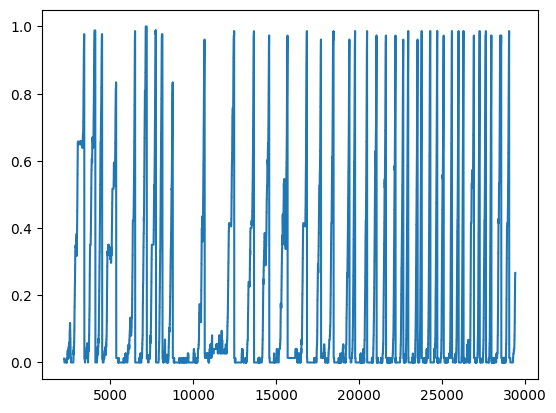

In [21]:
plt.plot(path_values_arr)

In [22]:
path_df = linear_position_df
path_df['path_progression'] = linear_position_df['trajectory_progress']

In [23]:
session_start = path_df['time'].iloc[0]

spike_times_relative = [spk - session_start for spk in spike_times]

# verify
path_end = path_df.index[-1]
for i in range(5):
    spk = spike_times_relative[i]
    n_in = np.sum((spk >= 0) & (spk <= path_end))
    print(f"neuron {i}: {n_in}/{len(spk)} spikes inside maze window")

neuron 0: 58980/73517 spikes inside maze window
neuron 1: 34201/36406 spikes inside maze window
neuron 2: 7934/9138 spikes inside maze window
neuron 3: 4888/6072 spikes inside maze window
neuron 4: 2783/2825 spikes inside maze window


In [68]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d

N_BINS = 20
SMOOTH_SIGMA = 1.0
MIN_OCCUPANCY_S = 0.05
N_SHUFFLES = 500
ALPHA = 0.05
SPEED_THRESHOLD = None
OUTPUT_DIR = "."

# EDIT: If your path_df has discontinuous path traversals, this prevents interpolation
# across large behavioral gaps. If None, it is inferred as 5 * median dt.
MAX_TIME_GAP_S = None


def get_contiguous_segments(
    times: np.ndarray,
    max_time_gap_s: float | None = None,
) -> list[slice]:
    """Find contiguous behavioral segments.

    Parameters
    ----------
    times : np.ndarray
        Time values with shape ``(n_time,)``.
    max_time_gap_s : float | None, default=None
        Maximum allowed gap between adjacent time samples. If None, use
        ``5 * median(diff(times))``.

    Returns
    -------
    segments : list[slice]
        List of slices defining contiguous time segments.
    """
    times = np.asarray(times, dtype=float)

    if times.size < 2:
        return [slice(0, times.size)]

    dt = np.diff(times)
    if max_time_gap_s is None:
        max_time_gap_s = 5.0 * float(np.nanmedian(dt))

    break_points = np.flatnonzero(dt > max_time_gap_s) + 1
    segment_starts = np.r_[0, break_points]
    segment_stops = np.r_[break_points, times.size]

    return [
        slice(start, stop)
        for start, stop in zip(segment_starts, segment_stops)
        if stop - start >= 2
    ]


def compute_tuning_curve(
    spike_times: np.ndarray,
    path_times: np.ndarray,
    path_values: np.ndarray,
    bins: np.ndarray,
    min_occupancy_s: float = MIN_OCCUPANCY_S,
    smooth_sigma: float = SMOOTH_SIGMA,
    max_time_gap_s: float | None = MAX_TIME_GAP_S,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute path-progression tuning curve for one neuron.

    Parameters
    ----------
    spike_times : np.ndarray
        Spike times for one neuron, with shape ``(n_spikes,)``.
    path_times : np.ndarray
        Behavioral timestamps, with shape ``(n_time,)``.
    path_values : np.ndarray
        Path-progression values aligned to ``path_times``, with shape
        ``(n_time,)``.
    bins : np.ndarray
        Path-progression bin edges, with shape ``(n_bins + 1,)``.
    min_occupancy_s : float, default=MIN_OCCUPANCY_S
        Minimum occupancy in seconds required for a bin to be valid.
    smooth_sigma : float, default=SMOOTH_SIGMA
        Gaussian smoothing sigma in bin units.
    max_time_gap_s : float | None, default=MAX_TIME_GAP_S
        Maximum allowed gap between adjacent behavioral time samples.
        This prevents interpolation across discontinuous path traversals.

    Returns
    -------
    rate : np.ndarray
        Firing rate in Hz, with shape ``(n_bins,)``.
    occupancy : np.ndarray
        Occupancy in seconds, with shape ``(n_bins,)``.
    """
    spike_times = np.asarray(spike_times, dtype=float)
    path_times = np.asarray(path_times, dtype=float)
    path_values = np.asarray(path_values, dtype=float)

    n_bins = len(bins) - 1

    finite_path_mask = np.isfinite(path_times) & np.isfinite(path_values)
    path_times = path_times[finite_path_mask]
    path_values = path_values[finite_path_mask]

    sort_order = np.argsort(path_times)
    path_times = path_times[sort_order]
    path_values = path_values[sort_order]

    occupancy = np.zeros(n_bins, dtype=float)
    counts = np.zeros(n_bins, dtype=float)

    segments = get_contiguous_segments(
        times=path_times,
        max_time_gap_s=max_time_gap_s,
    )

    for segment in segments:
        segment_times = path_times[segment]
        segment_values = path_values[segment]

        if segment_times.size < 2:
            continue

        dt = float(np.nanmedian(np.diff(segment_times)))

        bin_idx = np.clip(
            np.digitize(segment_values, bins) - 1,
            0,
            n_bins - 1,
        )
        occupancy += np.bincount(bin_idx, minlength=n_bins) * dt

        # EDIT: Only use spikes inside this actual behavioral segment.
        in_segment = (
            (spike_times >= segment_times[0])
            & (spike_times <= segment_times[-1])
        )
        segment_spike_times = spike_times[in_segment]

        if segment_spike_times.size == 0:
            continue

        # EDIT: left/right NaN prevents endpoint clamping by np.interp.
        spike_pos = np.interp(
            segment_spike_times,
            segment_times,
            segment_values,
            left=np.nan,
            right=np.nan,
        )

        valid_spike_pos = (
            np.isfinite(spike_pos)
            & (spike_pos >= bins[0])
            & (spike_pos <= bins[-1])
        )
        spike_pos = spike_pos[valid_spike_pos]

        segment_counts, _ = np.histogram(spike_pos, bins=bins)
        counts += segment_counts

    rate = np.full(n_bins, np.nan)
    valid = occupancy > min_occupancy_s
    rate[valid] = counts[valid] / occupancy[valid]

    if smooth_sigma > 0:
        filled = np.where(valid, rate, 0.0)
        smoothed = gaussian_filter1d(filled, sigma=smooth_sigma)

        valid_smoothed = gaussian_filter1d(valid.astype(float), sigma=smooth_sigma)
        with np.errstate(invalid="ignore", divide="ignore"):
            smoothed = np.where(
                valid_smoothed > 0.01,
                smoothed / valid_smoothed,
                np.nan,
            )

        rate = np.where(valid, smoothed, np.nan)

    return rate, occupancy


def run_shuffle_test(
    spike_times: np.ndarray,
    path_times: np.ndarray,
    path_values: np.ndarray,
    bins: np.ndarray,
    n_shuffles: int = N_SHUFFLES,
    max_time_gap_s: float | None = MAX_TIME_GAP_S,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute circular-shift shuffle null distribution.

    Parameters
    ----------
    spike_times : np.ndarray
        Spike times for one neuron, with shape ``(n_spikes,)``.
    path_times : np.ndarray
        Behavioral timestamps, with shape ``(n_time,)``.
    path_values : np.ndarray
        Path-progression values aligned to ``path_times``, with shape
        ``(n_time,)``.
    bins : np.ndarray
        Path-progression bin edges, with shape ``(n_bins + 1,)``.
    n_shuffles : int, default=N_SHUFFLES
        Number of circular shuffles.
    max_time_gap_s : float | None, default=MAX_TIME_GAP_S
        Maximum allowed gap between adjacent behavioral samples.

    Returns
    -------
    p95_per_bin : np.ndarray
        Per-bin shuffle threshold, with shape ``(n_bins,)``.
    mean_per_bin : np.ndarray
        Per-bin shuffle mean, with shape ``(n_bins,)``.
    """
    path_times = np.asarray(path_times, dtype=float)
    spike_times = np.asarray(spike_times, dtype=float)

    t_start = float(path_times[0])
    t_stop = float(path_times[-1])
    total_duration = t_stop - t_start

    shuffle_rates = np.full((n_shuffles, len(bins) - 1), np.nan)

    for i_shuffle in range(n_shuffles):
        # EDIT: Keep the original absolute time origin.
        shift = np.random.uniform(20.0, total_duration - 20.0)
        shuffled = ((spike_times - t_start + shift) % total_duration) + t_start

        rate, _ = compute_tuning_curve(
            spike_times=shuffled,
            path_times=path_times,
            path_values=path_values,
            bins=bins,
            max_time_gap_s=max_time_gap_s,
        )
        shuffle_rates[i_shuffle] = rate

    return (
        np.nanpercentile(shuffle_rates, 100 * (1 - ALPHA), axis=0),
        np.nanmean(shuffle_rates, axis=0),
    )


def safe_row_normalize(rates: np.ndarray) -> np.ndarray:
    """Normalize each row to its maximum finite value.

    Parameters
    ----------
    rates : np.ndarray
        Tuning curves with shape ``(n_neurons, n_bins)``.

    Returns
    -------
    norm_rates : np.ndarray
        Row-normalized tuning curves with shape ``(n_neurons, n_bins)``.
    """
    rates = np.asarray(rates, dtype=float)

    row_max = np.nanmax(rates, axis=1, keepdims=True)
    row_max = np.where(np.isfinite(row_max) & (row_max > 0), row_max, 1.0)

    return rates / row_max



In [45]:
path_df

0                   NaN
1                   NaN
2                   NaN
3                   NaN
4                   NaN
              ...      
29403    left_to_center
29404    left_to_center
29405    left_to_center
29406    left_to_center
29407    left_to_center
Name: trajectory, Length: 29408, dtype: object

In [69]:
traj_names = [
    "center_to_right",
    "left_to_right",
    "center_to_left",
    "left_to_center",
    "right_to_center",
    "right_to_left",
]

traj_labels = {
    "center_to_right": "Center → Right",
    "left_to_right": "Left → Right",
    "center_to_left": "Center → Left",
    "left_to_center": "Left → Center",
    "right_to_center": "Right → Center",
    "right_to_left": "Right → Left",
}

# traj_dfs should be a dict like:
# traj_dfs["center_to_right"] = path_df for that trajectory
# traj_dfs["left_to_right"]   = path_df for that trajectory
# etc.

all_rates_by_traj = {}
shuffle_p95_by_traj = {}
is_significant_by_traj = {}

for traj in traj_names:

    session_start = path_df["time"].iloc[0]
    spike_times_relative = [spk - session_start for spk in spike_times]

    path_times_arr = path_df.index.to_numpy(dtype=float)
    path_values_arr = path_df["path_progression"].to_numpy(dtype=float)

    n_neurons = len(spike_times_relative)
    all_rates = np.full((n_neurons, N_BINS), np.nan)
    shuffle_p95_all = np.full((n_neurons, N_BINS), np.nan)
    is_significant = np.zeros(n_neurons, dtype=bool)

    for i, spk in enumerate(spike_times_relative):
        if spk.size < 10:
            continue

        rate, _ = compute_tuning_curve(spk, path_times_arr, path_values_arr, bins)
        all_rates[i] = rate

        p95, _ = run_shuffle_test(spk, path_times_arr, path_values_arr, bins)
        shuffle_p95_all[i] = p95

        if np.all(np.isnan(rate)) or np.all(np.isnan(p95)):
            continue

        peak = np.nanargmax(rate)
        if np.isfinite(rate[peak]) and np.isfinite(p95[peak]):
            is_significant[i] = rate[peak] > p95[peak]

    all_rates_by_traj[traj] = all_rates
    shuffle_p95_by_traj[traj] = shuffle_p95_all
    is_significant_by_traj[traj] = is_significant

# neurons significant in at least one trajectory
sig_neurons = np.where(np.any(np.stack(list(is_significant_by_traj.values())), axis=0))[0]
print(f"{len(sig_neurons)} neurons significant in at least one trajectory")

5 neurons significant in at least one trajectory


In [25]:
session_start = path_df['time'].iloc[0]
spike_times_relative = [spk - session_start for spk in spike_times]

N_BINS = 20

path_times_arr  = path_df.index.to_numpy(dtype=float)
path_values_arr = path_df["path_progression"].to_numpy(dtype=float)

n_neurons = len(spike_times_relative)
all_rates = np.full((n_neurons, N_BINS), np.nan)

print(f"Computing tuning curves for {n_neurons} neurons ...")
for i, spk in enumerate(spike_times_relative):
    all_rates[i], _ = compute_tuning_curve(spk, path_times_arr, path_values_arr, bins)

for i, spk in enumerate(spike_times_relative):
    if spk.size < 10:
        continue
    p95, _ = run_shuffle_test(spk, path_times_arr, path_values_arr, bins)
is_significant  = np.zeros(n_neurons, dtype=bool)
shuffle_p95_all = np.full((n_neurons, N_BINS), np.nan)

for i, spk in enumerate(spike_times_relative):
    if spk.size < 10:
        continue
    p95, _             = run_shuffle_test(spk, path_times_arr, path_values_arr, bins)
    shuffle_p95_all[i] = p95
    peak               = int(np.nanargmax(all_rates[i]))
    if not np.isnan(all_rates[i, peak]) and not np.isnan(p95[peak]):
        is_significant[i]  = all_rates[i, peak] > p95[peak]

n_sig = int(is_significant.sum())
print(f"{n_sig}/{n_neurons} neurons significantly tuned (α={ALPHA})")

row_max    = np.where(np.nanmax(all_rates, axis=1, keepdims=True) == 0, 1,
                      np.nanmax(all_rates, axis=1, keepdims=True))
norm_rates = all_rates / row_max
peak_bin   = np.nanargmax(norm_rates, axis=1)
sort_order = np.argsort(peak_bin)
bin_centers = (bins[:-1] + bins[1:]) / 2

Computing tuning curves for 62 neurons ...
4/62 neurons significantly tuned (α=0.05)


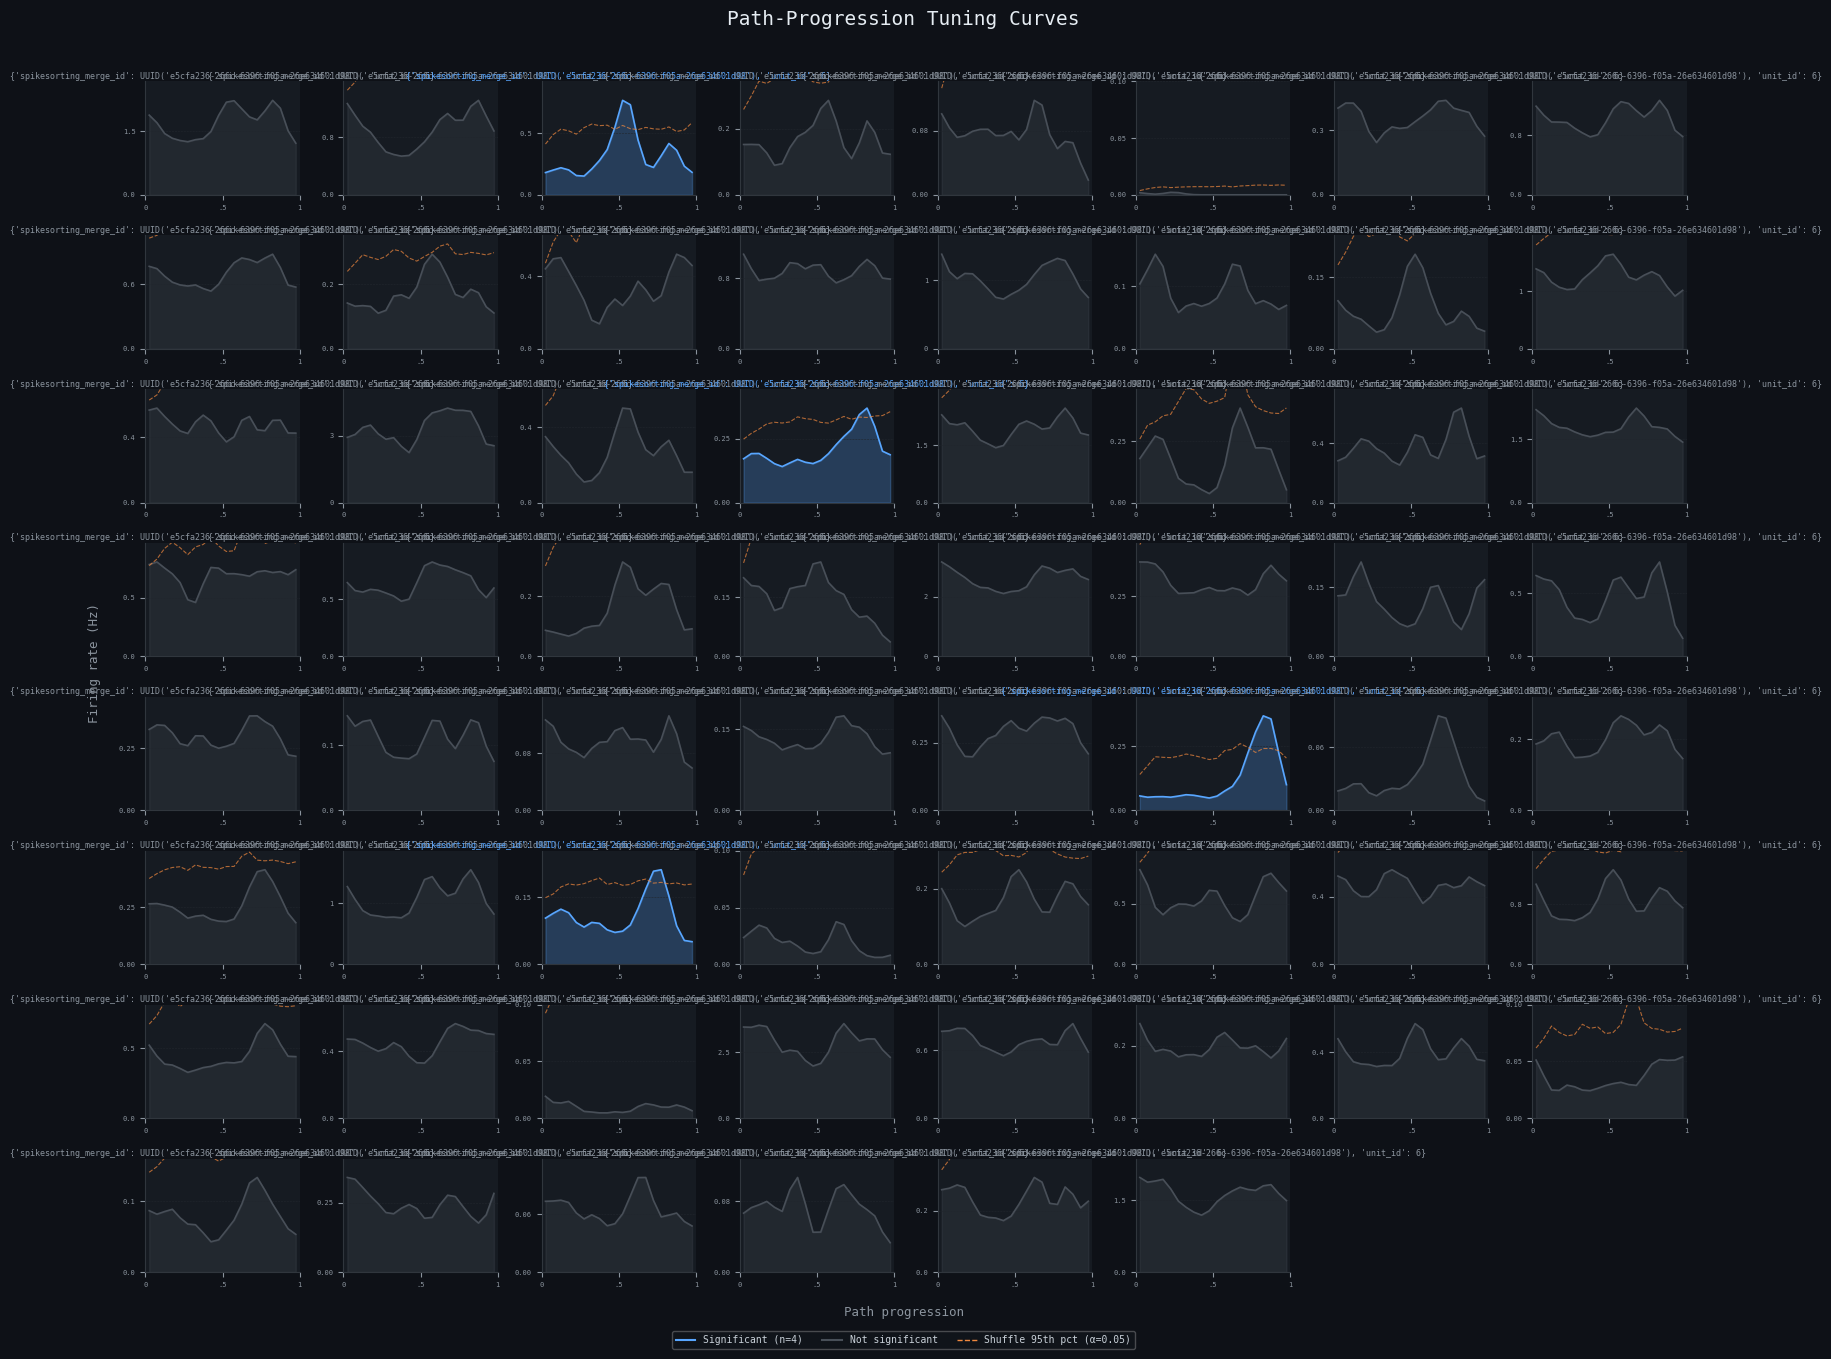

/tmp/ipykernel_1860127/1619782664.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


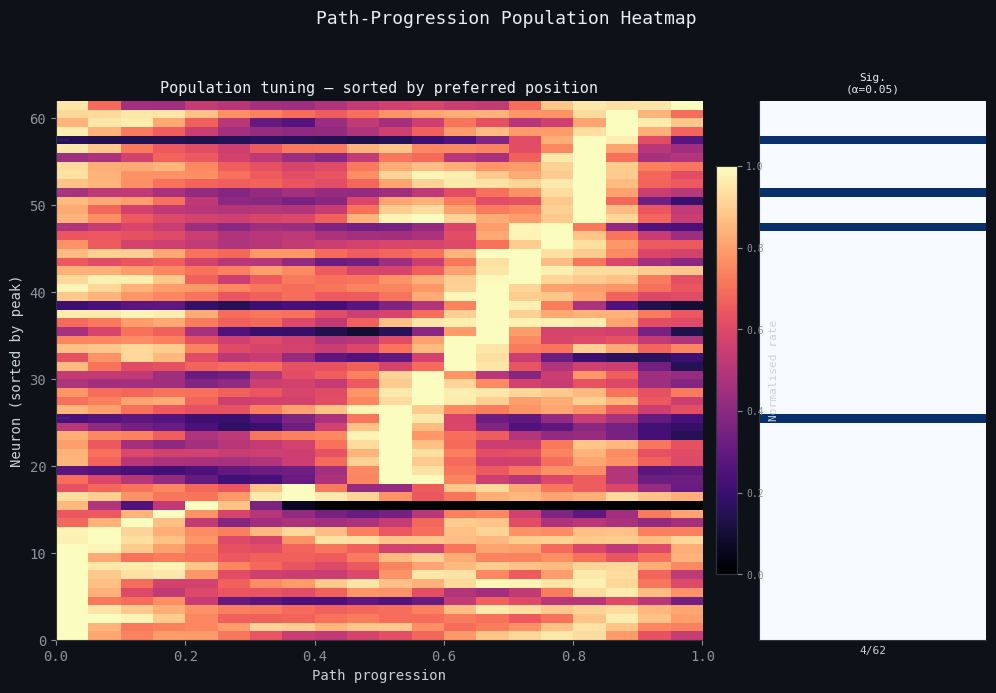

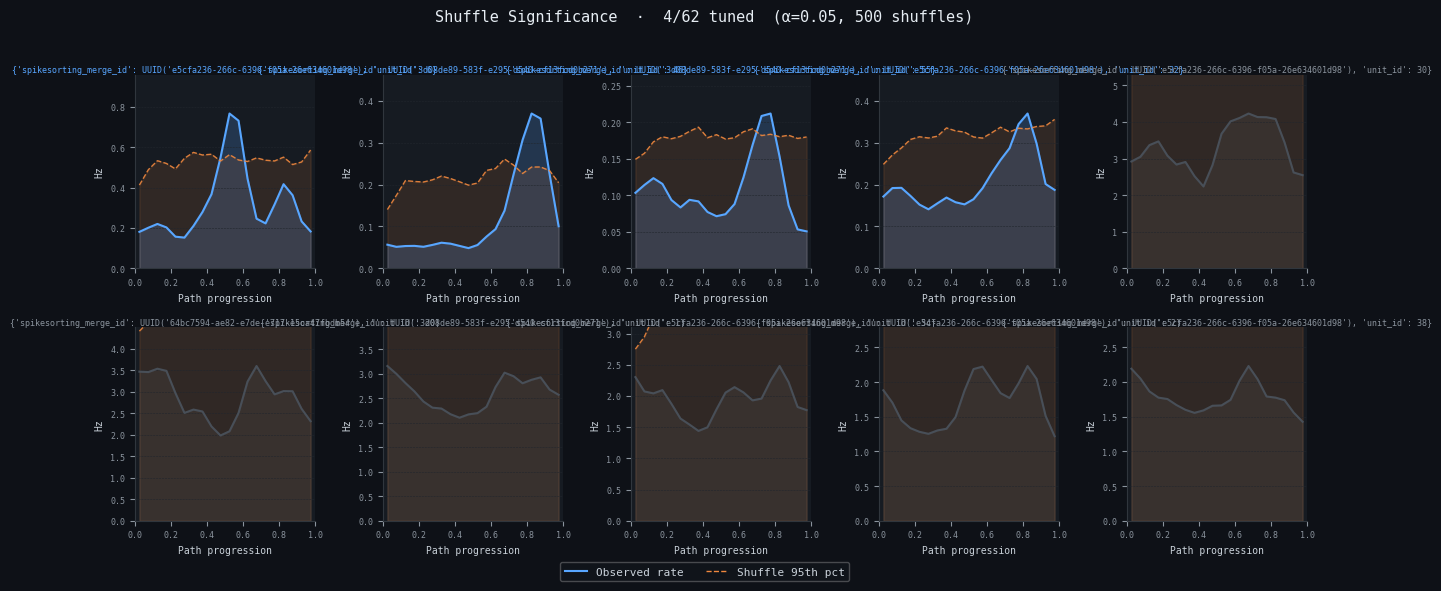

In [29]:
plt.rcParams.update(
    {
        "figure.facecolor": "#0e1117",
        "axes.facecolor": "#161b22",
        "axes.edgecolor": "#30363d",
        "axes.labelcolor": "#c9d1d9",
        "axes.titlecolor": "#e6edf3",
        "xtick.color": "#8b949e",
        "ytick.color": "#8b949e",
        "text.color": "#c9d1d9",
        "grid.color": "#21262d",
        "grid.linestyle": "--",
        "grid.linewidth": 0.5,
        "font.family": "monospace",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

SIG_COLOR = "#58a6ff"
INSIG_COLOR = "#484f58"
SHUF_COLOR = "#f0883e"

# ── Plot: per-neuron tuning curve grid ───────────────────────────────────────

n_cols = 8
n_rows = int(np.ceil(n_neurons / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 2.0, n_rows * 1.6),
    facecolor="#0e1117",
    squeeze=False,
)
fig.suptitle("Path-Progression Tuning Curves", fontsize=14, color="#e6edf3", y=1.01)

for idx in range(n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col]
    if idx >= n_neurons:
        ax.set_visible(False)
        continue
    rate = all_rates[idx]
    p95 = shuffle_p95_all[idx]
    sig = is_significant[idx]
    color = SIG_COLOR if sig else INSIG_COLOR
    ax.fill_between(bin_centers, np.nan_to_num(rate), alpha=0.25, color=color)
    ax.plot(bin_centers, rate, color=color, lw=1.2)
    if not np.all(np.isnan(p95)):
        ax.plot(bin_centers, p95, color=SHUF_COLOR, lw=0.8, linestyle="--", alpha=0.7)
    peak = np.nanmax(rate) if not np.all(np.isnan(rate)) else 0
    ax.set_ylim(0, max(peak * 1.2, 0.1))
    ax.set_xlim(0, 1)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(["0", ".5", "1"], fontsize=5)
    ax.tick_params(axis="y", labelsize=5)
    ax.set_title(f"{unit_ids[neuron_idx]}",
    fontsize=6,
    pad=2,
    color=SIG_COLOR if sig else "#8b949e",
)
    ax.yaxis.set_major_locator(plt.MaxNLocator(2))
    ax.grid(True, axis="y", linewidth=0.4)

fig.text(0.5, -0.01, "Path progression", ha="center", fontsize=9, color="#8b949e")
fig.text(-0.01, 0.5, "Firing rate (Hz)", va="center", rotation="vertical", fontsize=9, color="#8b949e")
fig.legend(
    handles=[
        Line2D([0], [0], color=SIG_COLOR, lw=1.5, label=f"Significant (n={n_sig})"),
        Line2D([0], [0], color=INSIG_COLOR, lw=1.5, label="Not significant"),
        Line2D([0], [0], color=SHUF_COLOR, lw=1.0, linestyle="--", label=f"Shuffle 95th pct (α={ALPHA})"),
    ],
    loc="lower center", ncol=3, fontsize=7, framealpha=0.3, bbox_to_anchor=(0.5, -0.04),
)
plt.tight_layout()
plt.show()

sig_indices = np.where(is_significant)[0]
insig_indices = np.where(~is_significant)[0]



# ── Plot: population heatmap ─────────────────────────────────────────────────

fig, axes = plt.subplots(
    1, 2, figsize=(12, 7),
    gridspec_kw={"width_ratios": [3, 1], "wspace": 0.05},
    facecolor="#0e1117",
)
sorted_norm = norm_rates[sort_order]
im = axes[0].imshow(
    sorted_norm, aspect="auto", origin="lower", cmap="magma",
    norm=Normalize(vmin=0, vmax=1), extent=[0, 1, 0, n_neurons], interpolation="nearest",
)
axes[0].set_xlabel("Path progression", fontsize=10)
axes[0].set_ylabel("Neuron (sorted by peak)", fontsize=10)
axes[0].set_title("Population tuning — sorted by preferred position", fontsize=11)
sig_sorted = is_significant[sort_order]
for y_idx, sig in enumerate(sig_sorted):
    if sig:
        axes[0].axhline(y_idx + 0.5, color=SIG_COLOR, lw=0.3, alpha=0.4, xmin=0, xmax=0.02)
cbar = fig.colorbar(im, ax=axes[0], fraction=0.03, pad=0.02)
cbar.set_label("Normalised rate", fontsize=8)
cbar.ax.tick_params(labelsize=7)
axes[1].imshow(
    sig_sorted.astype(float).reshape(-1, 1), aspect="auto", origin="lower",
    cmap="Blues", vmin=0, vmax=1, extent=[0, 1, 0, n_neurons], interpolation="nearest",
)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].set_title(f"Sig.\n(α={ALPHA})", fontsize=8)
axes[1].set_xlabel(f"{n_sig}/{n_neurons}", fontsize=8)
fig.suptitle("Path-Progression Population Heatmap", fontsize=13, color="#e6edf3", y=1.01)
plt.tight_layout()
plt.show()

# ── Plot: shuffle significance examples ──────────────────────────────────────

sig_indices = np.where(is_significant)[0]
# insig_indices = np.where(~is_significant & has_valid_rate)[0]

if sig_indices.size > 0:
    margins = np.array([
        np.nanmax(all_rates[i]) - np.nanmax(shuffle_p95_all[i])
        if not np.all(np.isnan(shuffle_p95_all[i])) else -np.inf
        for i in sig_indices
    ])
    top_sig = sig_indices[np.argsort(-margins)[:6]]
else:
    top_sig = np.array([], dtype=int)

if insig_indices.size > 0:
    insig_peak_rates = np.array([
        np.nanmax(all_rates[i]) if not np.all(np.isnan(all_rates[i])) else -np.inf
        for i in insig_indices
    ])
    top_insig = insig_indices[np.argsort(-insig_peak_rates)[:6]]
else:
    top_insig = np.array([], dtype=int)

example_neurons = np.concatenate([top_sig, top_insig]).astype(int)
n_examples = len(example_neurons)

if n_examples > 0:
    n_cols_ex = max(int(np.ceil(n_examples / 2)), 1)
    fig, axes = plt.subplots(
        2, n_cols_ex, figsize=(n_cols_ex * 2.5, 5.5),
        facecolor="#0e1117", sharey=False, squeeze=False,
    )
    fig.suptitle(
        f"Shuffle Significance  ·  {n_sig}/{n_neurons} tuned  (α={ALPHA}, {N_SHUFFLES} shuffles)",
        fontsize=11, color="#e6edf3", y=1.02,
    )
    for plot_idx, neuron_idx in enumerate(example_neurons):
        row = plot_idx // n_cols_ex
        col = plot_idx % n_cols_ex
        ax = axes[row, col]
        rate = all_rates[neuron_idx]
        p95 = shuffle_p95_all[neuron_idx]
        sig = is_significant[neuron_idx]
        color = SIG_COLOR if sig else INSIG_COLOR
        ax.fill_between(bin_centers, np.nan_to_num(rate), alpha=0.2, color=color)
        ax.plot(bin_centers, rate, color=color, lw=1.5)
        if not np.all(np.isnan(p95)):
            ax.fill_between(bin_centers, np.nan_to_num(p95), alpha=0.12, color=SHUF_COLOR)
            ax.plot(bin_centers, p95, color=SHUF_COLOR, lw=1.0, linestyle="--", alpha=0.9)
        peak = np.nanmax(rate) if not np.all(np.isnan(rate)) else 0
        ax.set_ylim(0, max(peak * 1.25, 0.1))
        ax.set_xlim(0, 1)
        ax.set_xlabel("Path progression", fontsize=7)
        ax.set_ylabel("Hz", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.set_title(
        f"{unit_ids[neuron_idx]}",
        fontsize=6,
        pad=2,
        color=SIG_COLOR if sig else "#8b949e",
    )
        ax.grid(True, axis="y", linewidth=0.4)

    for plot_idx in range(n_examples, axes.size):
        axes[plot_idx // n_cols_ex, plot_idx % n_cols_ex].set_visible(False)

    fig.legend(
        handles=[
            Line2D([0], [0], color=SIG_COLOR, lw=1.5, label="Observed rate"),
            Line2D([0], [0], color=SHUF_COLOR, lw=1.0, linestyle="--", label="Shuffle 95th pct"),
        ],
        loc="lower center", ncol=2, fontsize=8, framealpha=0.3, bbox_to_anchor=(0.5, -0.03),
    )
    plt.tight_layout()
    plt.show()
else:
    print("No valid example neurons to plot.")

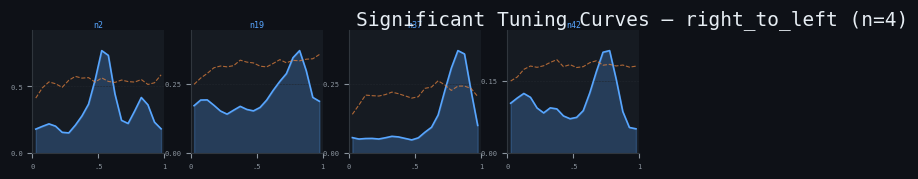

In [32]:
sig_indices = np.where(is_significant)[0]
n_sig_neurons = len(sig_indices)

n_cols = 8
n_rows = int(np.ceil(n_sig_neurons / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 2.0, n_rows * 1.6),
                         facecolor="#0e1117")
axes = np.atleast_2d(axes)  # safe if only 1 row
fig.suptitle(f"Significant Tuning Curves — {traj} (n={n_sig_neurons})",
             fontsize=14, color="#e6edf3", y=1.01)

for plot_idx in range(n_rows * n_cols):
    row, col = divmod(plot_idx, n_cols)
    ax = axes[row, col]
    if plot_idx >= n_sig_neurons:
        ax.set_visible(False)
        continue
    neuron_idx = sig_indices[plot_idx]   # ← actual neuron index
    rate  = all_rates[neuron_idx]
    p95   = shuffle_p95_all[neuron_idx]

    ax.fill_between(bin_centers, np.nan_to_num(rate), alpha=0.25, color=SIG_COLOR)
    ax.plot(bin_centers, rate, color=SIG_COLOR, lw=1.2)
    if not np.all(np.isnan(p95)):
        ax.plot(bin_centers, p95, color=SHUF_COLOR, lw=0.8, linestyle="--", alpha=0.7)
    peak = np.nanmax(rate) if not np.all(np.isnan(rate)) else 0
    ax.set_ylim(0, max(peak * 1.2, 0.1))
    ax.set_xlim(0, 1)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(["0", ".5", "1"], fontsize=5)
    ax.tick_params(axis="y", labelsize=5)
    ax.set_title(f"n{neuron_idx}", fontsize=6, pad=2, color=SIG_COLOR)
    ax.yaxis.set_major_locator(plt.MaxNLocator(2))
    ax.grid(True, axis="y", linewidth=0.4)

In [34]:
traj = 'right_to_center' #'right_to_left'

In [37]:
# ============================================================================
# Restrict analysis to a single trajectory
# ============================================================================

TRAJECTORY = "center_to_right"
N_BINS = 20

traj_df = path_df[path_df["trajectory"] == TRAJECTORY].copy()

if len(traj_df) == 0:
    raise ValueError(f"No samples found for trajectory '{TRAJECTORY}'")

print(f"Trajectory: {TRAJECTORY}")
print(f"Samples: {len(traj_df)}")

# --------------------------------------------------------------------------
# Time alignment
# --------------------------------------------------------------------------

session_start = path_df["time"].iloc[0]
spike_times_relative = [spk - session_start for spk in spike_times]

# --------------------------------------------------------------------------
# Path progression arrays (trajectory-restricted)
# --------------------------------------------------------------------------

path_times_arr = traj_df.index.to_numpy(dtype=float)
path_values_arr = traj_df["path_progression"].to_numpy(dtype=float)

# --------------------------------------------------------------------------
# Binning
# --------------------------------------------------------------------------

bins = np.linspace(0, 1, N_BINS + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2

# --------------------------------------------------------------------------
# Compute tuning curves
# --------------------------------------------------------------------------

n_neurons = len(spike_times_relative)

all_rates = np.full((n_neurons, N_BINS), np.nan)
shuffle_p95_all = np.full((n_neurons, N_BINS), np.nan)
is_significant = np.zeros(n_neurons, dtype=bool)

print(f"Computing tuning curves for {n_neurons} neurons...")

for i, spk in enumerate(spike_times_relative):

    all_rates[i], _ = compute_tuning_curve(
        spk,
        path_times_arr,
        path_values_arr,
        bins,
    )

# --------------------------------------------------------------------------
# Shuffle significance
# --------------------------------------------------------------------------

print(f"Running shuffle tests ({N_SHUFFLES} shuffles/neuron)...")

for i, spk in enumerate(spike_times_relative):

    if spk.size < 10:
        continue

    p95, _ = run_shuffle_test(
        spk,
        path_times_arr,
        path_values_arr,
        bins,
    )

    shuffle_p95_all[i] = p95

    if np.all(np.isnan(all_rates[i])):
        continue

    peak_bin = np.nanargmax(all_rates[i])

    if (
        not np.isnan(all_rates[i, peak_bin])
        and not np.isnan(p95[peak_bin])
    ):
        is_significant[i] = (
            all_rates[i, peak_bin] > p95[peak_bin]
        )

# --------------------------------------------------------------------------
# Summary
# --------------------------------------------------------------------------

n_sig = int(is_significant.sum())

print(
    f"{n_sig}/{n_neurons} neurons significantly tuned "
    f"for {TRAJECTORY} (α={ALPHA})"
)

# --------------------------------------------------------------------------
# Population heatmap preparation
# --------------------------------------------------------------------------

row_max = np.nanmax(all_rates, axis=1, keepdims=True)

row_max[np.isnan(row_max)] = 1
row_max[row_max == 0] = 1

norm_rates = all_rates / row_max

peak_bin = np.nanargmax(
    np.nan_to_num(norm_rates, nan=-np.inf),
    axis=1,
)

sort_order = np.argsort(peak_bin)

# --------------------------------------------------------------------------
# Example neurons
# --------------------------------------------------------------------------

sig_indices = np.where(is_significant)[0]
insig_indices = np.where(~is_significant)[0]

if len(sig_indices):

    margins = np.array([
        (
            np.nanmax(all_rates[i])
            - np.nanmax(shuffle_p95_all[i])
        )
        if not np.all(np.isnan(shuffle_p95_all[i]))
        else -np.inf
        for i in sig_indices
    ])

    top_sig = sig_indices[np.argsort(-margins)[:6]]

else:
    top_sig = np.array([], dtype=int)

if len(insig_indices):

    peaks = np.array([
        np.nanmax(all_rates[i])
        if not np.all(np.isnan(all_rates[i]))
        else -np.inf
        for i in insig_indices
    ])

    top_insig = insig_indices[np.argsort(-peaks)[:6]]

else:
    top_insig = np.array([], dtype=int)

example_neurons = np.concatenate(
    [top_sig, top_insig]
).astype(int)

print(f"Selected {len(example_neurons)} example neurons")

Trajectory: center_to_right
Samples: 3230
Computing tuning curves for 62 neurons...
Running shuffle tests (500 shuffles/neuron)...
8/62 neurons significantly tuned for center_to_right (α=0.05)
Selected 12 example neurons


In [ ]:
# ============================================================================
# Restrict analysis to a single trajectory
# ============================================================================

TRAJECTORY = "right_to_center"
N_BINS = 20

traj_df = path_df[path_df["trajectory"] == TRAJECTORY].copy()

if len(traj_df) == 0:
    raise ValueError(f"No samples found for trajectory '{TRAJECTORY}'")

print(f"Trajectory: {TRAJECTORY}")
print(f"Samples: {len(traj_df)}")

# --------------------------------------------------------------------------
# Time alignment
# --------------------------------------------------------------------------

session_start = path_df["time"].iloc[0]
spike_times_relative = [spk - session_start for spk in spike_times]

# --------------------------------------------------------------------------
# Path progression arrays (trajectory-restricted)
# --------------------------------------------------------------------------

path_times_arr = traj_df.index.to_numpy(dtype=float)
path_values_arr = traj_df["path_progression"].to_numpy(dtype=float)

# --------------------------------------------------------------------------
# Binning
# --------------------------------------------------------------------------

bins = np.linspace(0, 1, N_BINS + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2

# --------------------------------------------------------------------------
# Compute tuning curves
# --------------------------------------------------------------------------

n_neurons = len(spike_times_relative)

all_rates = np.full((n_neurons, N_BINS), np.nan)
shuffle_p95_all = np.full((n_neurons, N_BINS), np.nan)
is_significant = np.zeros(n_neurons, dtype=bool)

print(f"Computing tuning curves for {n_neurons} neurons...")

for i, spk in enumerate(spike_times_relative):

    all_rates[i], _ = compute_tuning_curve(
        spk,
        path_times_arr,
        path_values_arr,
        bins,
    )

# --------------------------------------------------------------------------
# Shuffle significance
# --------------------------------------------------------------------------

print(f"Running shuffle tests ({N_SHUFFLES} shuffles/neuron)...")

for i, spk in enumerate(spike_times_relative):

    if spk.size < 10:
        continue

    p95, _ = run_shuffle_test(
        spk,
        path_times_arr,
        path_values_arr,
        bins,
    )

    shuffle_p95_all[i] = p95

    if np.all(np.isnan(all_rates[i])):
        continue

    peak_bin = np.nanargmax(all_rates[i])

    if (
        not np.isnan(all_rates[i, peak_bin])
        and not np.isnan(p95[peak_bin])
    ):
        is_significant[i] = (
            all_rates[i, peak_bin] > p95[peak_bin]
        )

# --------------------------------------------------------------------------
# Summary
# --------------------------------------------------------------------------

n_sig = int(is_significant.sum())

print(
    f"{n_sig}/{n_neurons} neurons significantly tuned "
    f"for {TRAJECTORY} (α={ALPHA})"
)

# --------------------------------------------------------------------------
# Population heatmap preparation
# --------------------------------------------------------------------------

row_max = np.nanmax(all_rates, axis=1, keepdims=True)

row_max[np.isnan(row_max)] = 1
row_max[row_max == 0] = 1

norm_rates = all_rates / row_max

peak_bin = np.nanargmax(
    np.nan_to_num(norm_rates, nan=-np.inf),
    axis=1,
)

sort_order = np.argsort(peak_bin)

# --------------------------------------------------------------------------
# Example neurons
# --------------------------------------------------------------------------

sig_indices = np.where(is_significant)[0]
insig_indices = np.where(~is_significant)[0]

if len(sig_indices):

    margins = np.array([
        (
            np.nanmax(all_rates[i])
            - np.nanmax(shuffle_p95_all[i])
        )
        if not np.all(np.isnan(shuffle_p95_all[i]))
        else -np.inf
        for i in sig_indices
    ])

    top_sig = sig_indices[np.argsort(-margins)[:6]]

else:
    top_sig = np.array([], dtype=int)

if len(insig_indices):

    peaks = np.array([
        np.nanmax(all_rates[i])
        if not np.all(np.isnan(all_rates[i]))
        else -np.inf
        for i in insig_indices
    ])

    top_insig = insig_indices[np.argsort(-peaks)[:6]]

else:
    top_insig = np.array([], dtype=int)

example_neurons = np.concatenate(
    [top_sig, top_insig]
).astype(int)


Trajectory: center_to_left
Samples: 6495
Computing tuning curves for 62 neurons...
Running shuffle tests (500 shuffles/neuron)...
1/62 neurons significantly tuned for center_to_left (α=0.05)


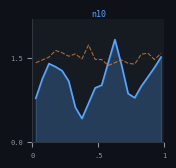

In [40]:
sig_indices = np.where(is_significant)[0]
n_sig_neurons = len(sig_indices)

n_cols = 8
n_rows = int(np.ceil(n_sig_neurons / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 2.0, n_rows * 1.6),
                         facecolor="#0e1117")
axes = np.atleast_2d(axes)  # safe if only 1 row
# fig.suptitle(f"Significant Tuning Curves — {traj} (n={n_sig_neurons})",
#              fontsize=14, color="#e6edf3", y=1.01)

for plot_idx in range(n_rows * n_cols):
    row, col = divmod(plot_idx, n_cols)
    ax = axes[row, col]
    if plot_idx >= n_sig_neurons:
        ax.set_visible(False)
        continue
    neuron_idx = sig_indices[plot_idx]   # ← actual neuron index
    rate  = all_rates[neuron_idx]
    p95   = shuffle_p95_all[neuron_idx]

    ax.fill_between(bin_centers, np.nan_to_num(rate), alpha=0.25, color=SIG_COLOR)
    ax.plot(bin_centers, rate, color=SIG_COLOR, lw=1.2)
    if not np.all(np.isnan(p95)):
        ax.plot(bin_centers, p95, color=SHUF_COLOR, lw=0.8, linestyle="--", alpha=0.7)
    peak = np.nanmax(rate) if not np.all(np.isnan(rate)) else 0
    ax.set_ylim(0, max(peak * 1.2, 0.1))
    ax.set_xlim(0, 1)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(["0", ".5", "1"], fontsize=5)
    ax.tick_params(axis="y", labelsize=5)
    ax.set_title(f"n{neuron_idx}", fontsize=6, pad=2, color=SIG_COLOR)
    ax.yaxis.set_major_locator(plt.MaxNLocator(2))
    ax.grid(True, axis="y", linewidth=0.4)

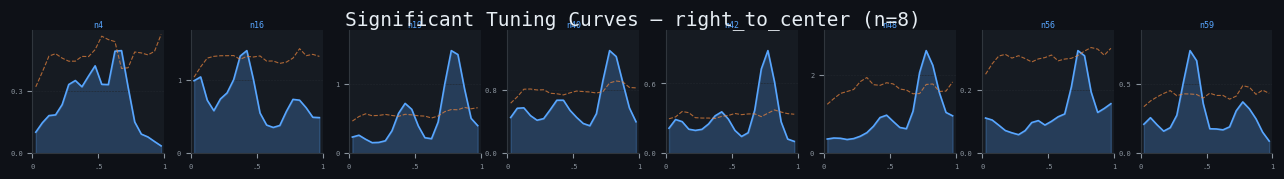

In [38]:
sig_indices = np.where(is_significant)[0]
n_sig_neurons = len(sig_indices)

n_cols = 8
n_rows = int(np.ceil(n_sig_neurons / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 2.0, n_rows * 1.6),
                         facecolor="#0e1117")
axes = np.atleast_2d(axes)  # safe if only 1 row
fig.suptitle(f"Significant Tuning Curves — {traj} (n={n_sig_neurons})",
             fontsize=14, color="#e6edf3", y=1.01)

for plot_idx in range(n_rows * n_cols):
    row, col = divmod(plot_idx, n_cols)
    ax = axes[row, col]
    if plot_idx >= n_sig_neurons:
        ax.set_visible(False)
        continue
    neuron_idx = sig_indices[plot_idx]   # ← actual neuron index
    rate  = all_rates[neuron_idx]
    p95   = shuffle_p95_all[neuron_idx]

    ax.fill_between(bin_centers, np.nan_to_num(rate), alpha=0.25, color=SIG_COLOR)
    ax.plot(bin_centers, rate, color=SIG_COLOR, lw=1.2)
    if not np.all(np.isnan(p95)):
        ax.plot(bin_centers, p95, color=SHUF_COLOR, lw=0.8, linestyle="--", alpha=0.7)
    peak = np.nanmax(rate) if not np.all(np.isnan(rate)) else 0
    ax.set_ylim(0, max(peak * 1.2, 0.1))
    ax.set_xlim(0, 1)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(["0", ".5", "1"], fontsize=5)
    ax.tick_params(axis="y", labelsize=5)
    ax.set_title(f"n{neuron_idx}", fontsize=6, pad=2, color=SIG_COLOR)
    ax.yaxis.set_major_locator(plt.MaxNLocator(2))
    ax.grid(True, axis="y", linewidth=0.4)

In [ ]:
# Cell 3 — trajectory-separated tuning curves
session_start = path_df['time'].iloc[0]
spike_times_relative = [spk - session_start for spk in spike_times]

bins        = np.linspace(0, 1, N_BINS + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
n_neurons   = len(spike_times_relative)
trajectories = [t for t in path_df['trajectory'].unique() if pd.notna(t)]
print(f"Found trajectories: {trajectories}")

# results are stored per trajectory
all_rates_by_traj       = {}
shuffle_p95_by_traj     = {}
is_significant_by_traj  = {}
norm_rates_by_traj      = {}
sort_order_by_traj      = {}

for traj in trajectories:
    print(f"\nTrajectory: {traj}")
    mask        = path_df['trajectory'] == traj
    traj_times  = path_df.index[mask].to_numpy(dtype=float)
    traj_values = path_df.loc[mask, 'path_progression'].to_numpy(dtype=float)

    all_rates = np.full((n_neurons, N_BINS), np.nan)
    print(f"  Computing tuning curves ({traj_times.size} samples) ...")
    for i, spk in enumerate(spike_times_relative):
        all_rates[i], _ = compute_tuning_curve(spk, traj_times, traj_values, bins)

    print(f"  Running {N_SHUFFLES} shuffles ...")
    shuffle_p95_all = np.full((n_neurons, N_BINS), np.nan)
    is_significant  = np.zeros(n_neurons, dtype=bool)
    for i, spk in enumerate(spike_times_relative):
        if spk.size < 10:
            continue
        p95, _             = run_shuffle_test(spk, traj_times, traj_values, bins)
        shuffle_p95_all[i] = p95
        peak               = int(np.nanargmax(all_rates[i]))
        if not np.isnan(all_rates[i, peak]) and not np.isnan(p95[peak]):
            is_significant[i] = all_rates[i, peak] > p95[peak]

    n_sig = int(is_significant.sum())
    print(f"  {n_sig}/{n_neurons} significant (α={ALPHA})")

    row_max    = np.where(np.nanmax(all_rates, axis=1, keepdims=True) == 0, 1,
                          np.nanmax(all_rates, axis=1, keepdims=True))
    norm_rates = all_rates / row_max
    peak_bin   = np.nanargmax(norm_rates, axis=1)

    all_rates_by_traj[traj]      = all_rates
    shuffle_p95_by_traj[traj]    = shuffle_p95_all
    is_significant_by_traj[traj] = is_significant
    norm_rates_by_traj[traj]     = norm_rates
    sort_order_by_traj[traj]     = np.argsort(peak_bin)

Found trajectories: ['left_to_right', 'right_to_left', 'left_to_center', 'center_to_right', 'center_to_left', 'right_to_center']

Trajectory: left_to_right
  Computing tuning curves (2008 samples) ...
  Running 500 shuffles ...
  1/62 significant (α=0.05)

Trajectory: right_to_left
  Computing tuning curves (2688 samples) ...
  Running 500 shuffles ...
  0/62 significant (α=0.05)

Trajectory: left_to_center
  Computing tuning curves (9485 samples) ...
  Running 500 shuffles ...
  0/62 significant (α=0.05)

Trajectory: center_to_right
  Computing tuning curves (3230 samples) ...
  Running 500 shuffles ...
  7/62 significant (α=0.05)

Trajectory: center_to_left
  Computing tuning curves (6495 samples) ...
  Running 500 shuffles ...
  1/62 significant (α=0.05)

Trajectory: right_to_center
  Computing tuning curves (3285 samples) ...
  Running 500 shuffles ...
  0/62 significant (α=0.05)


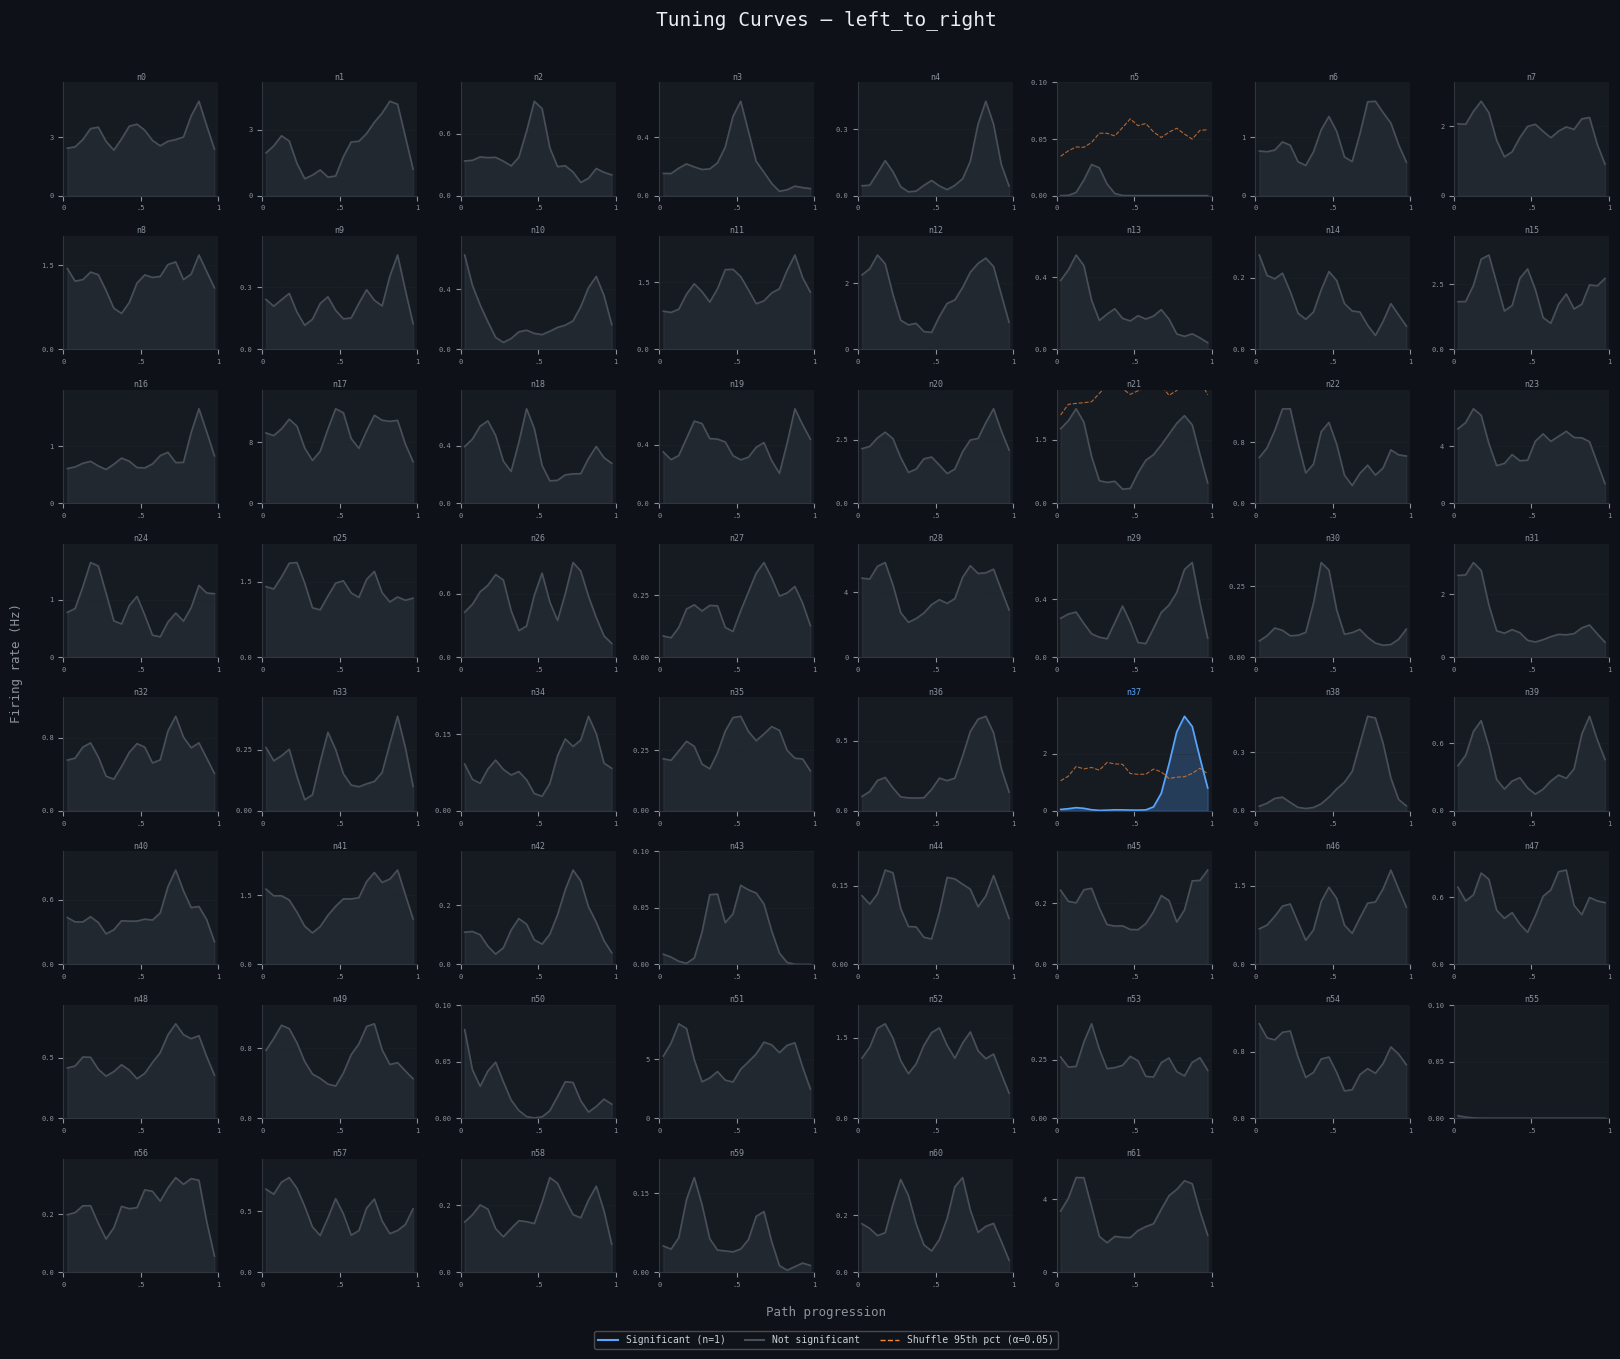

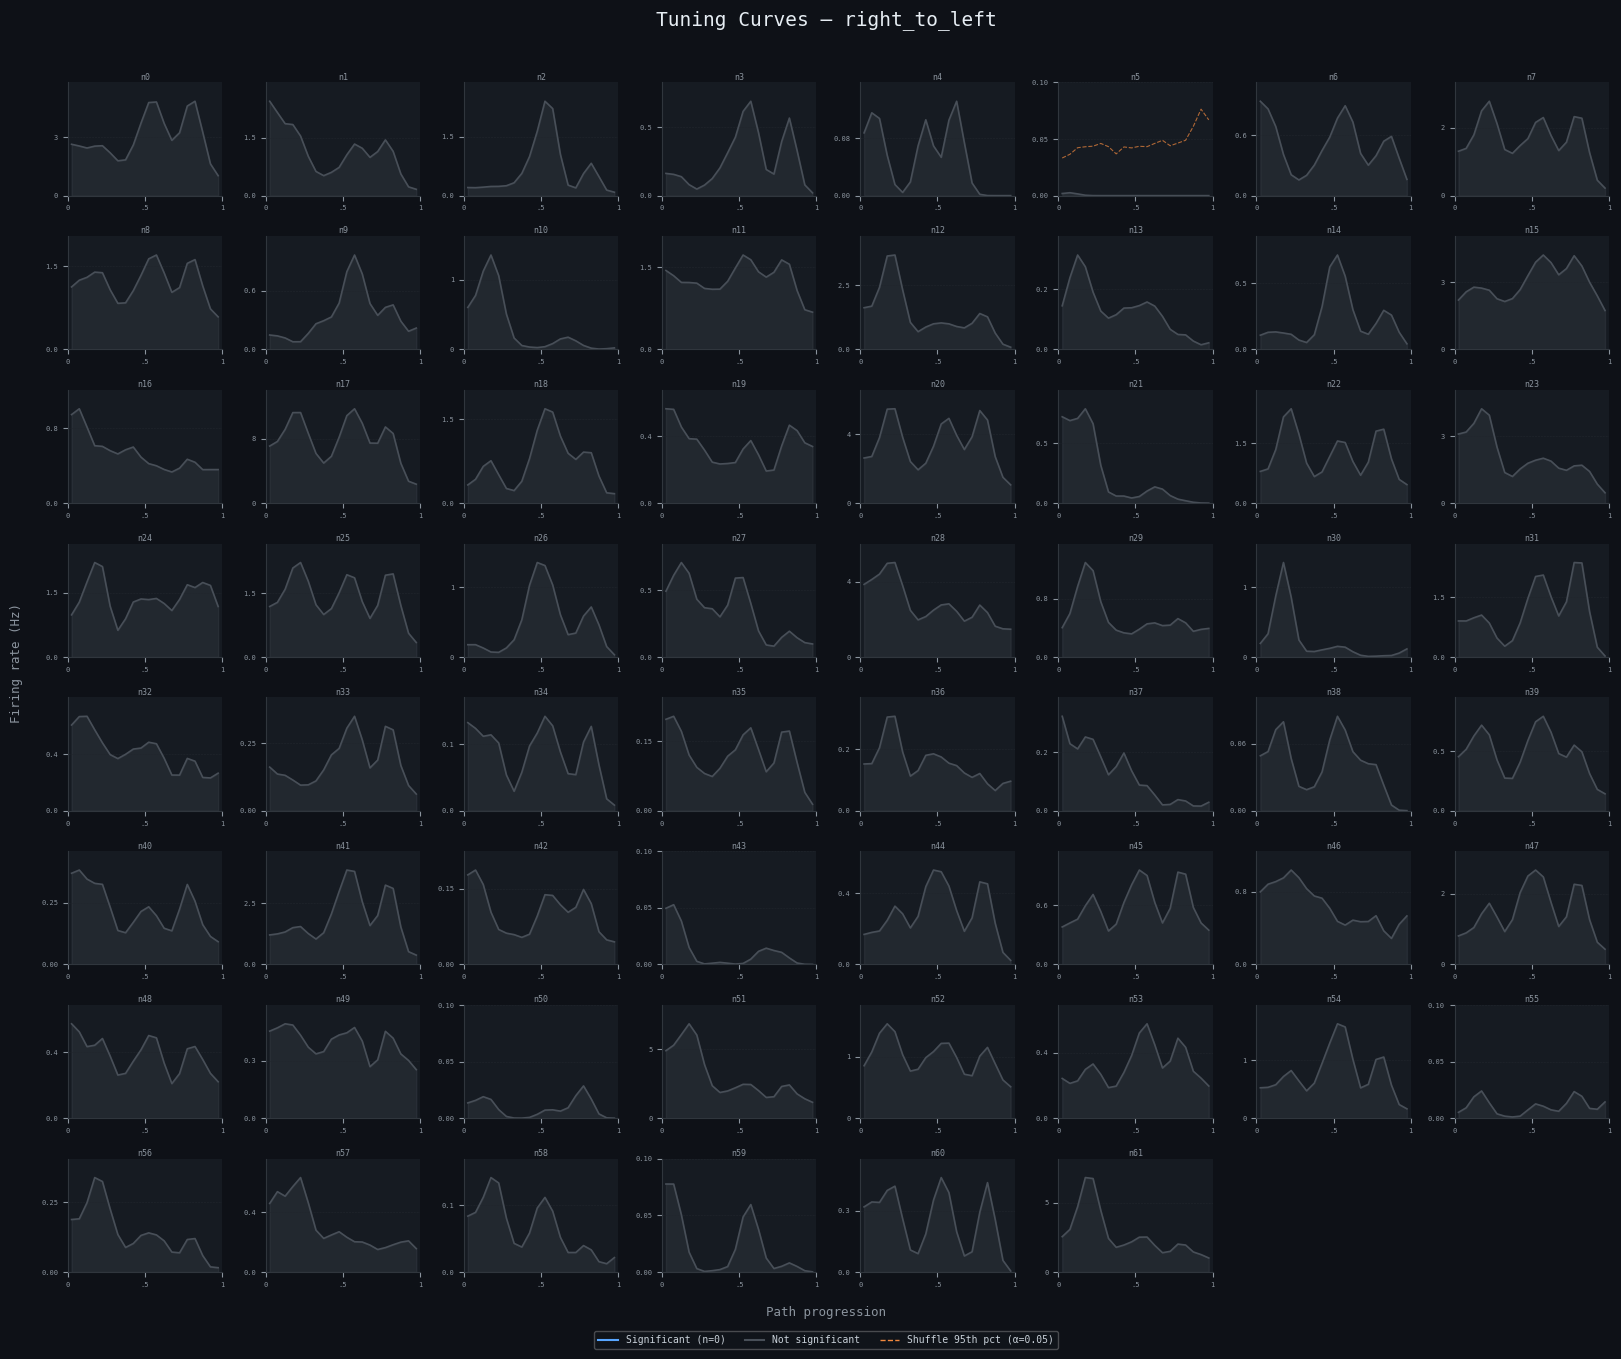

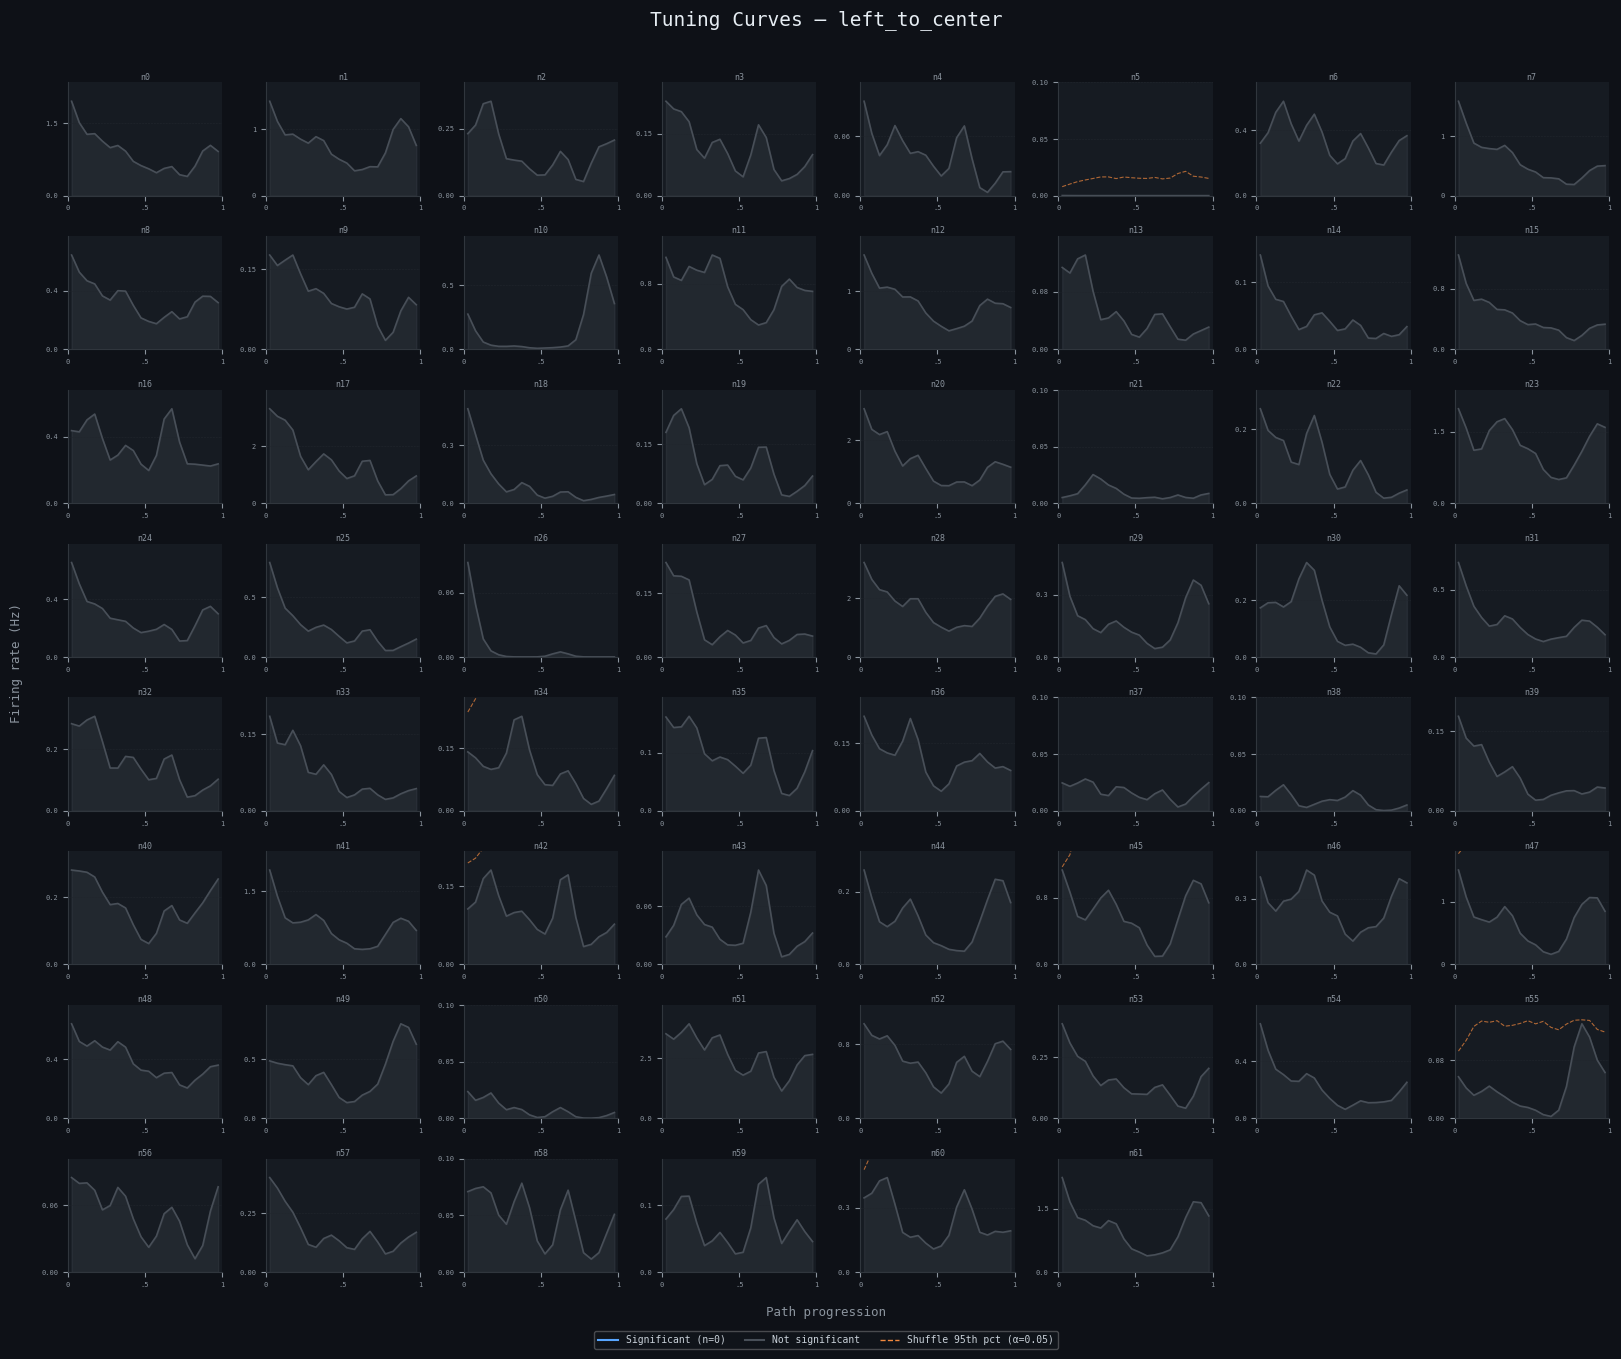

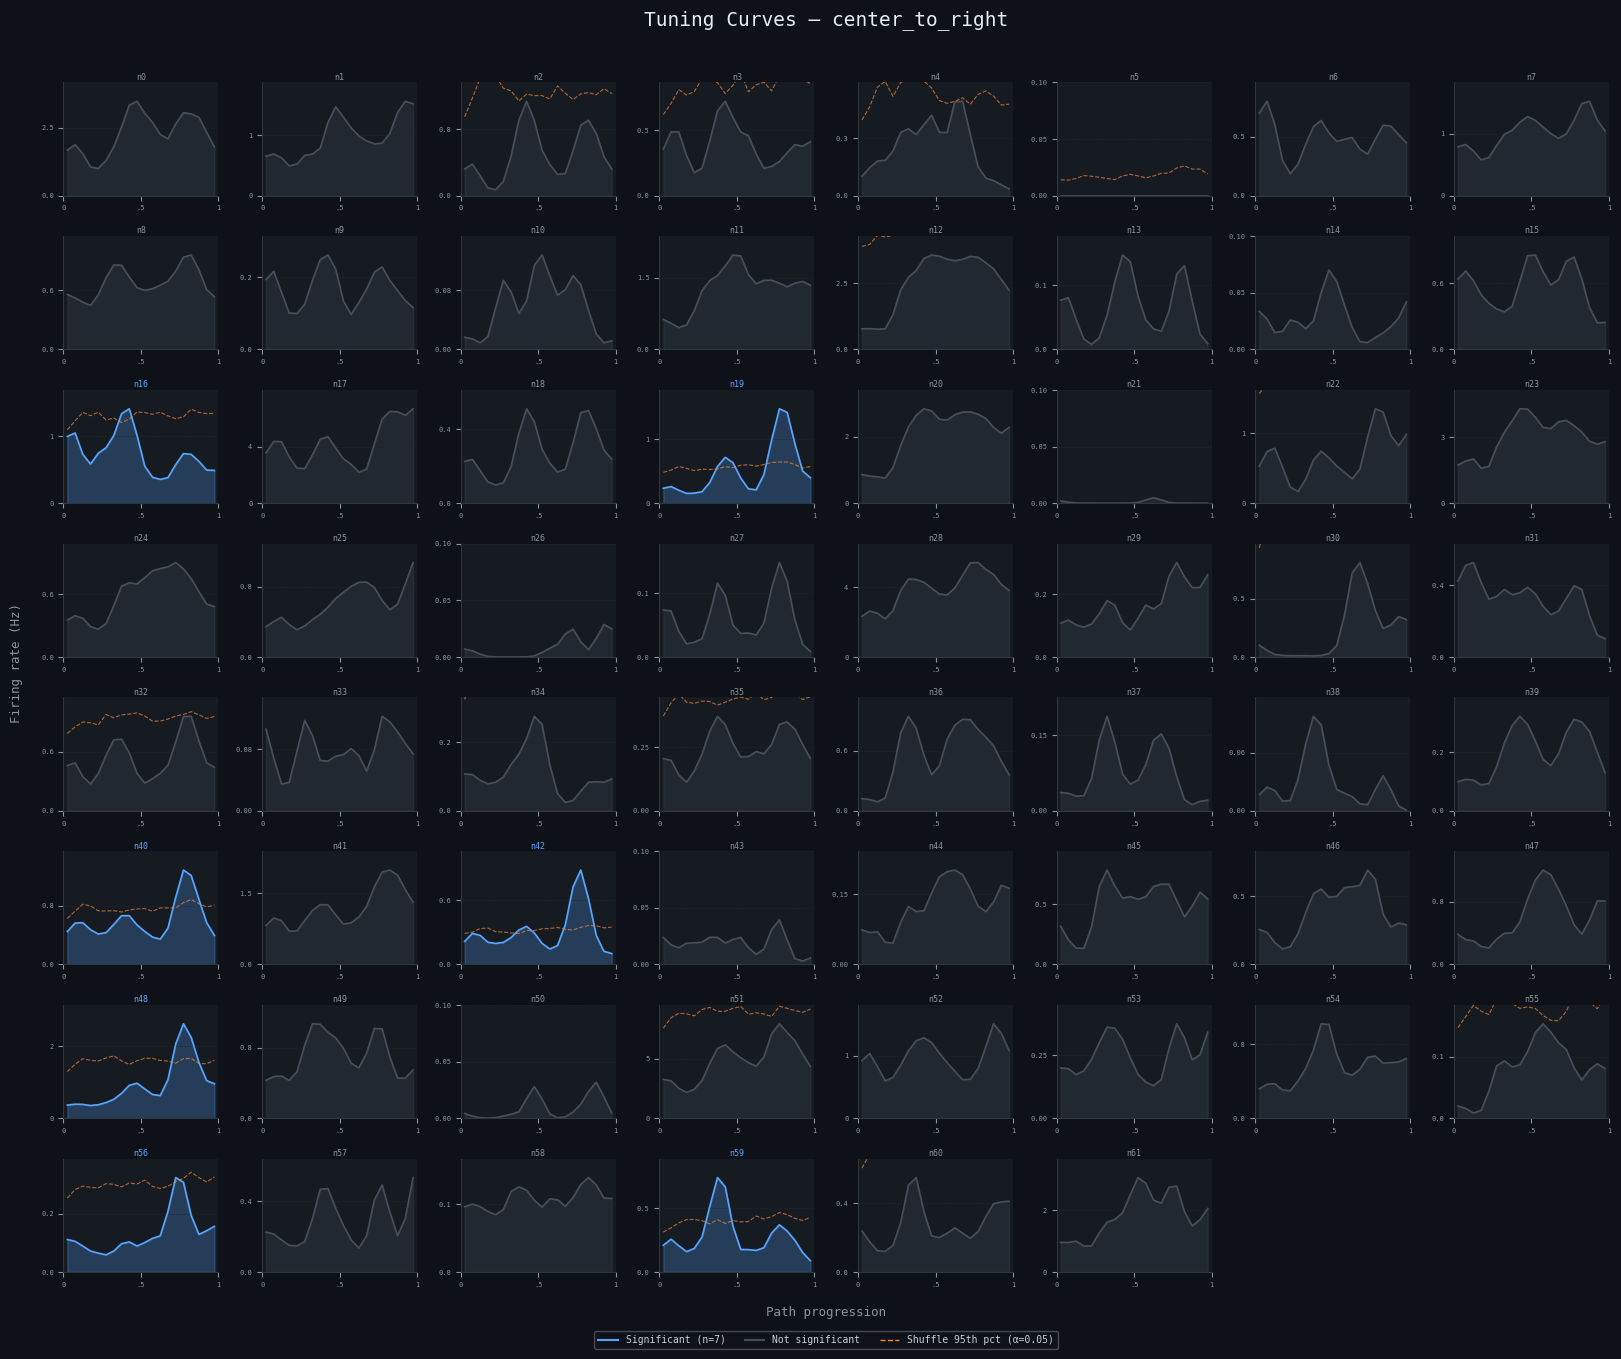

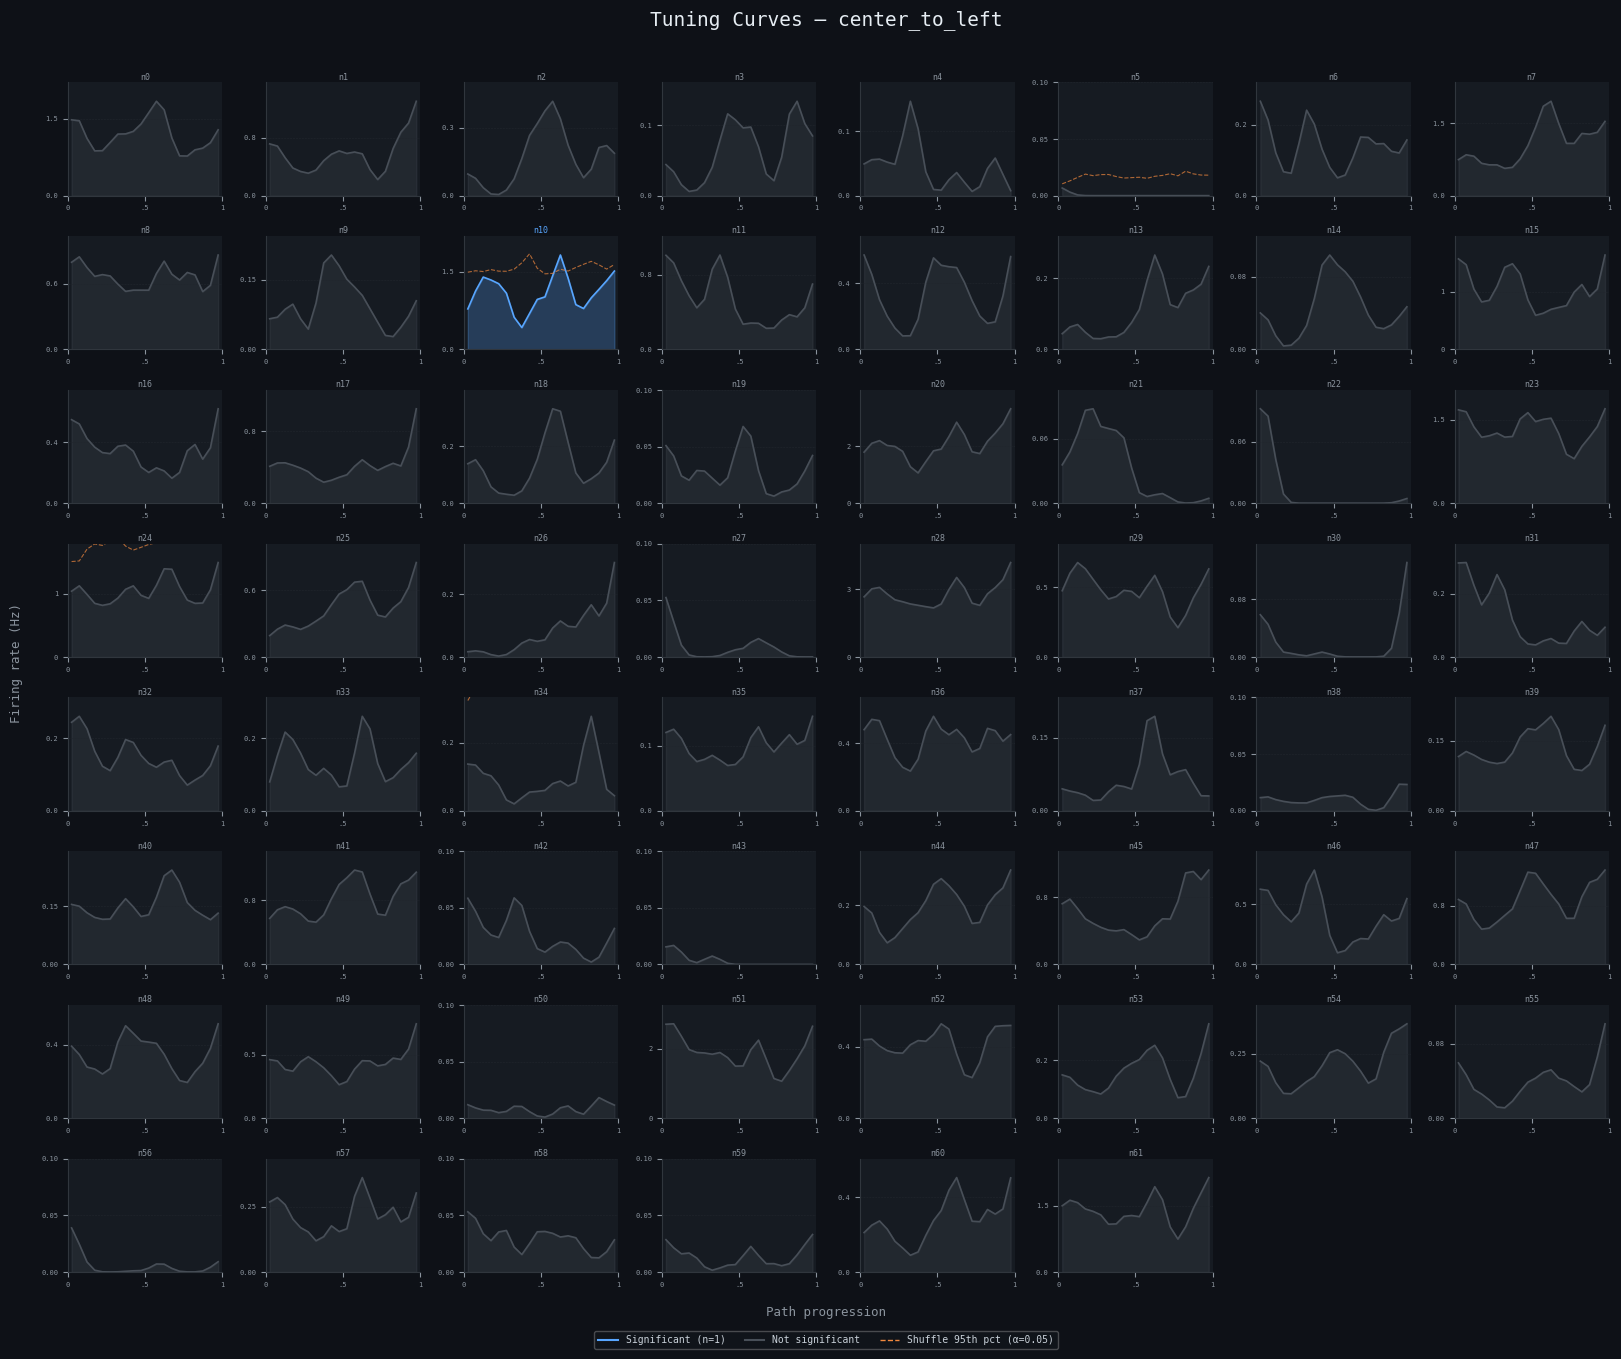

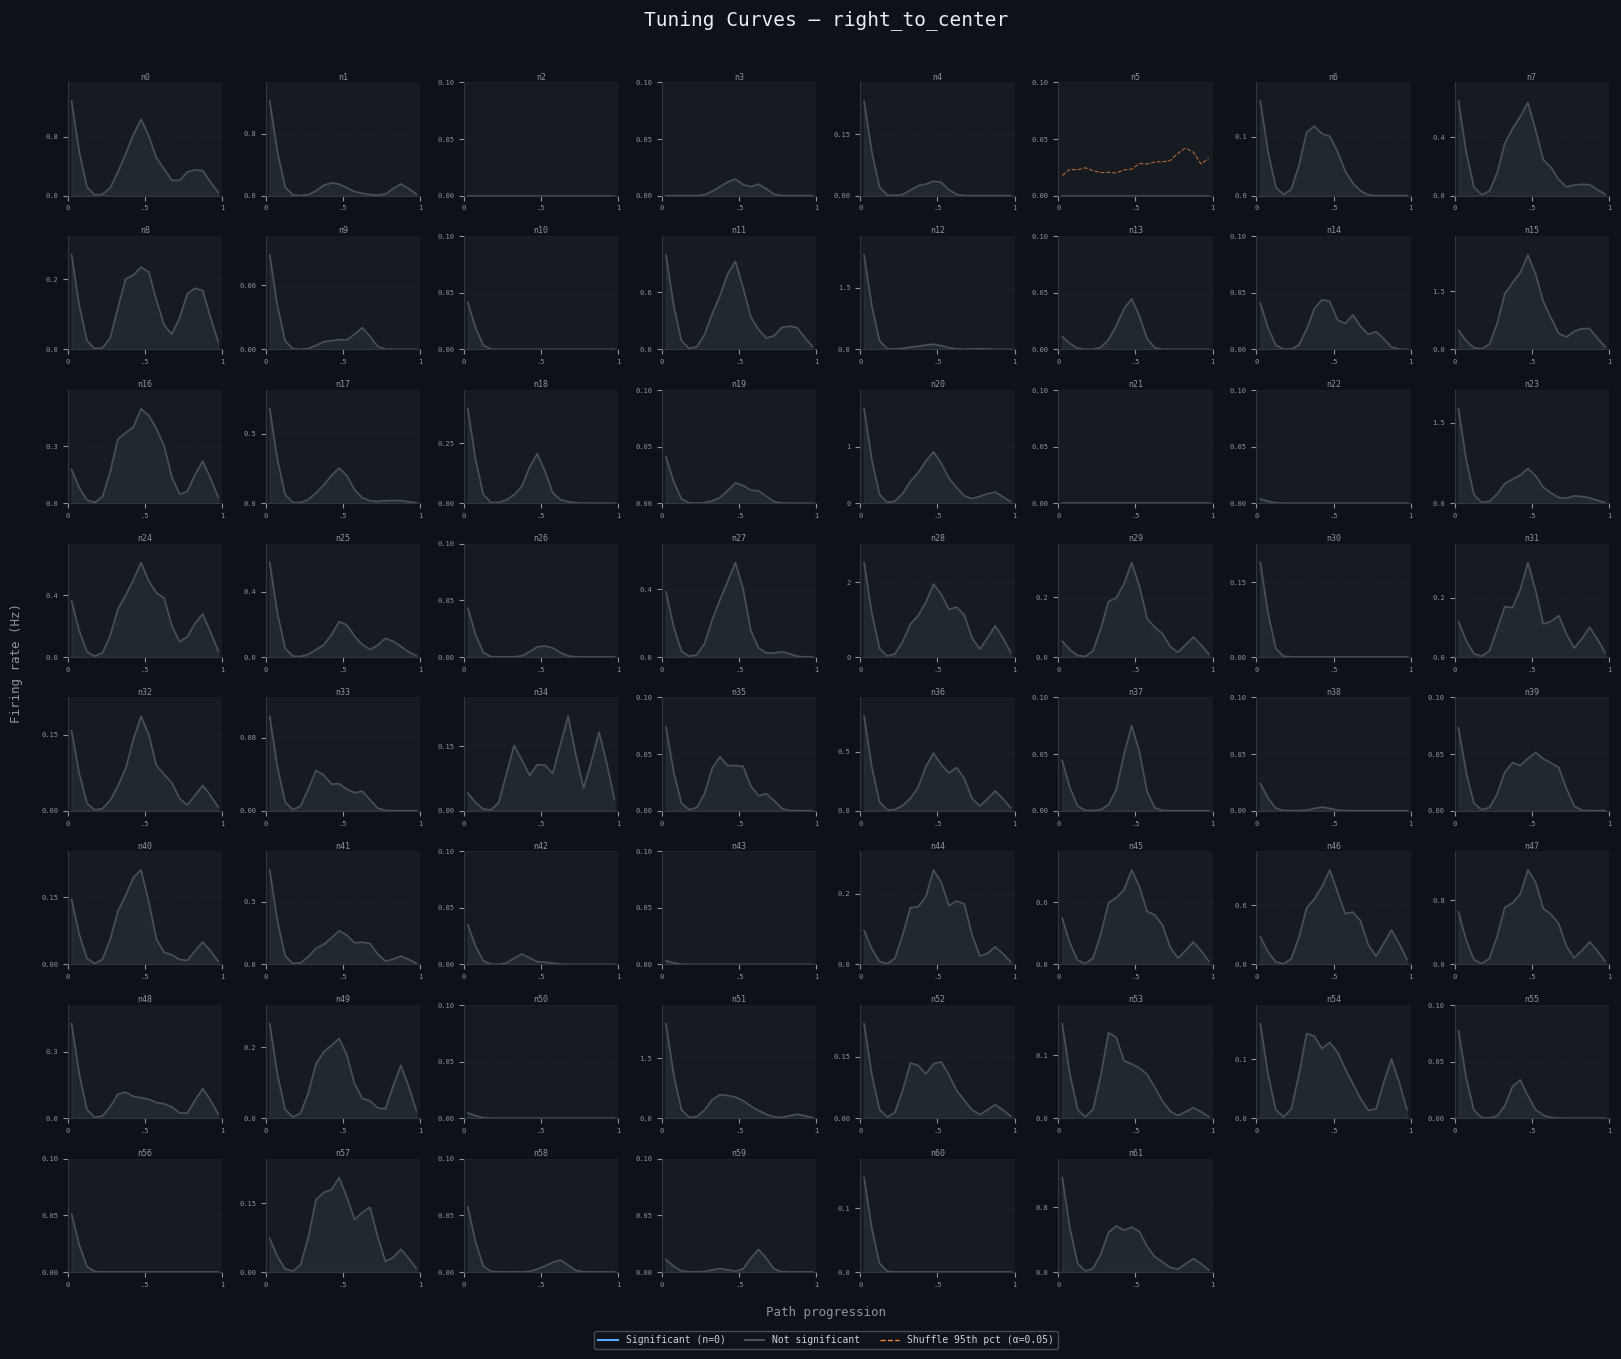

In [ ]:
# Cell 5 — per-neuron grid, one figure per trajectory
for traj in trajectories:
    all_rates       = all_rates_by_traj[traj]
    shuffle_p95_all = shuffle_p95_by_traj[traj]
    is_significant  = is_significant_by_traj[traj]
    n_sig           = int(is_significant.sum())

    n_cols = 8
    n_rows = int(np.ceil(n_neurons / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 2.0, n_rows * 1.6),
                             facecolor="#0e1117")
    fig.suptitle(f"Tuning Curves — {traj}", fontsize=14, color="#e6edf3", y=1.01)

    for idx in range(n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        ax = axes[row, col]
        if idx >= n_neurons:
            ax.set_visible(False)
            continue
        rate  = all_rates[idx]
        p95   = shuffle_p95_all[idx]
        sig   = is_significant[idx]
        color = SIG_COLOR if sig else INSIG_COLOR

        ax.fill_between(bin_centers, np.nan_to_num(rate), alpha=0.25, color=color)
        ax.plot(bin_centers, rate, color=color, lw=1.2)
        if not np.all(np.isnan(p95)):
            ax.plot(bin_centers, p95, color=SHUF_COLOR, lw=0.8,
                    linestyle="--", alpha=0.7)
        peak = np.nanmax(rate) if not np.all(np.isnan(rate)) else 0
        ax.set_ylim(0, max(peak * 1.2, 0.1))
        ax.set_xlim(0, 1)
        ax.set_xticks([0, 0.5, 1])
        ax.set_xticklabels(["0", ".5", "1"], fontsize=5)
        ax.tick_params(axis="y", labelsize=5)
        ax.set_title(f"n{idx}", fontsize=6, pad=2,
                     color=SIG_COLOR if sig else "#8b949e")
        ax.yaxis.set_major_locator(plt.MaxNLocator(2))
        ax.grid(True, axis="y", linewidth=0.4)

    fig.text(0.5, -0.01, "Path progression", ha="center", fontsize=9, color="#8b949e")
    fig.text(-0.01, 0.5, "Firing rate (Hz)", va="center", rotation="vertical",
             fontsize=9, color="#8b949e")
    fig.legend(handles=[
        Line2D([0], [0], color=SIG_COLOR,   lw=1.5, label=f"Significant (n={n_sig})"),
        Line2D([0], [0], color=INSIG_COLOR, lw=1.5, label="Not significant"),
        Line2D([0], [0], color=SHUF_COLOR,  lw=1.0, linestyle="--",
               label=f"Shuffle 95th pct (α={ALPHA})"),
    ], loc="lower center", ncol=3, fontsize=7, framealpha=0.3,
       bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/tuning_curves_grid_{traj}.png", dpi=150,
                bbox_inches="tight", facecolor="#0e1117")
    plt.show()

/tmp/ipykernel_930154/2210979889.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


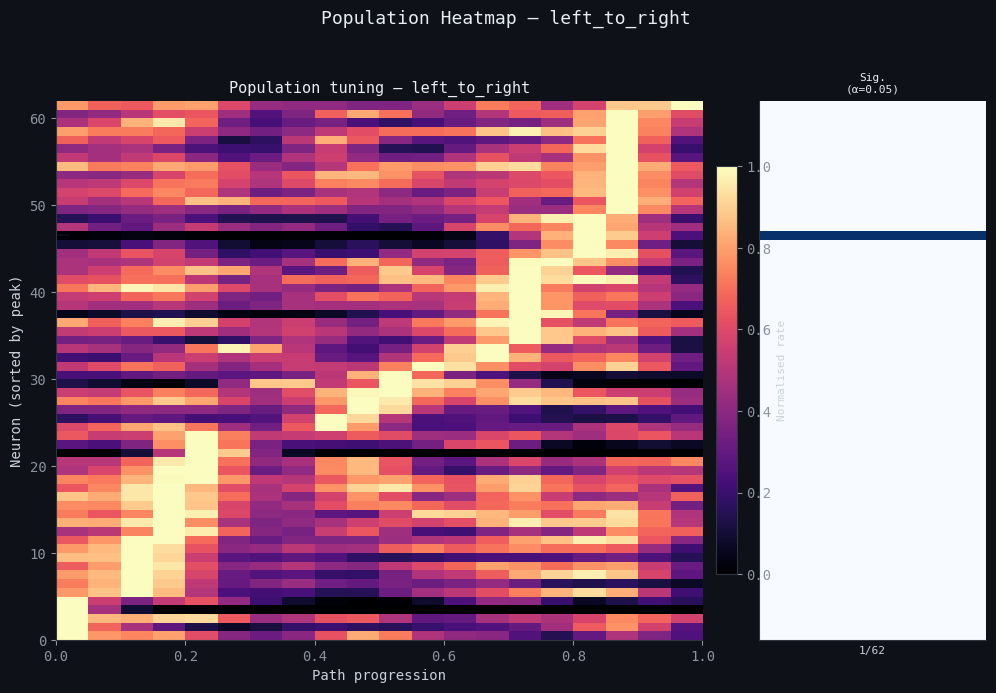

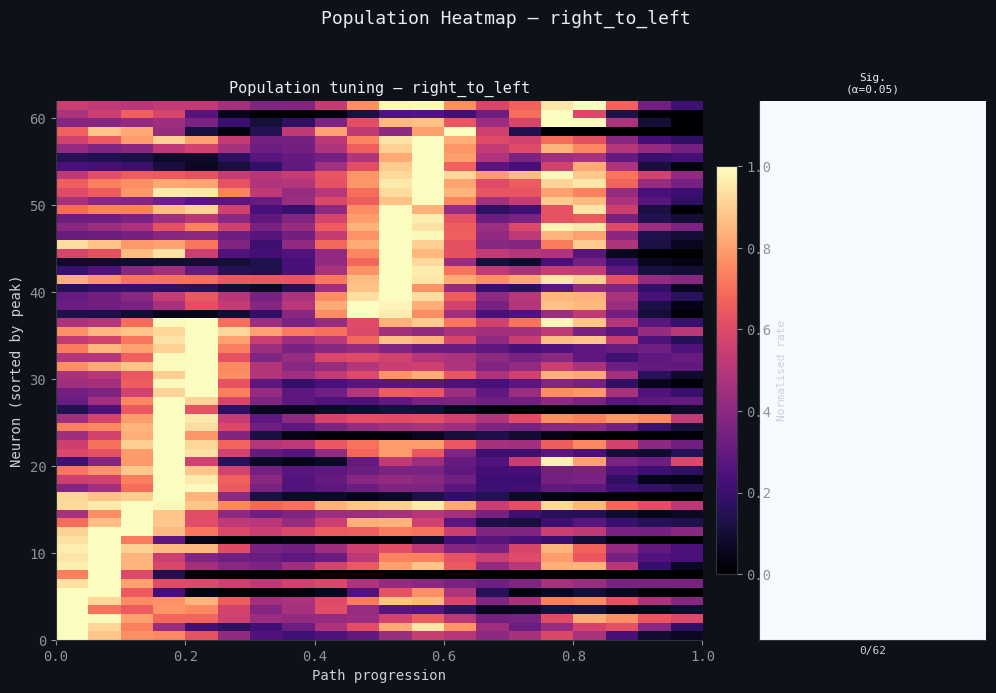

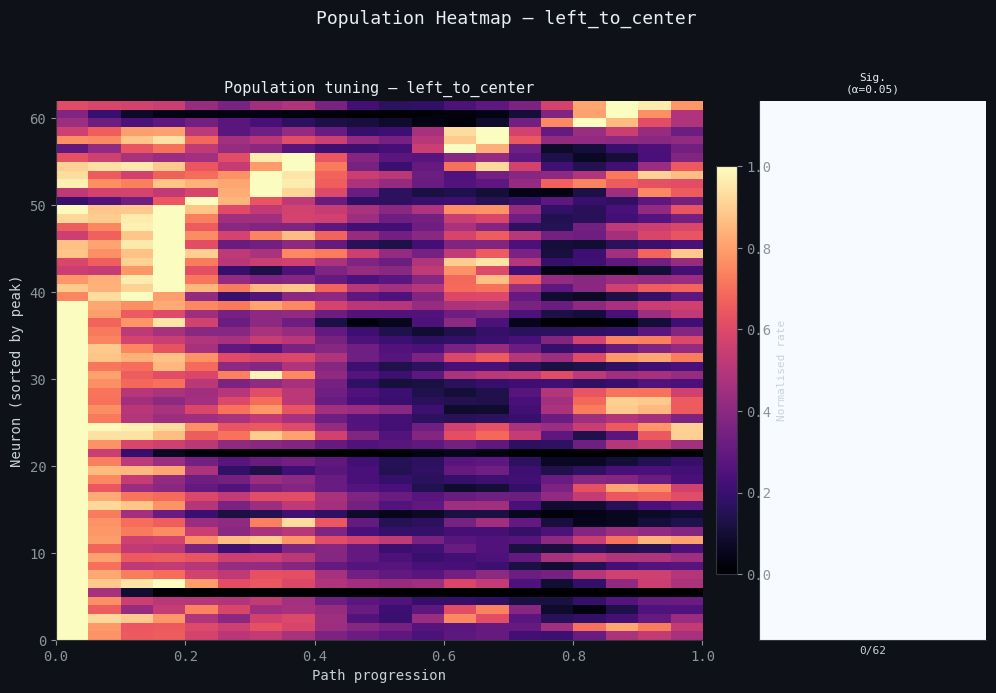

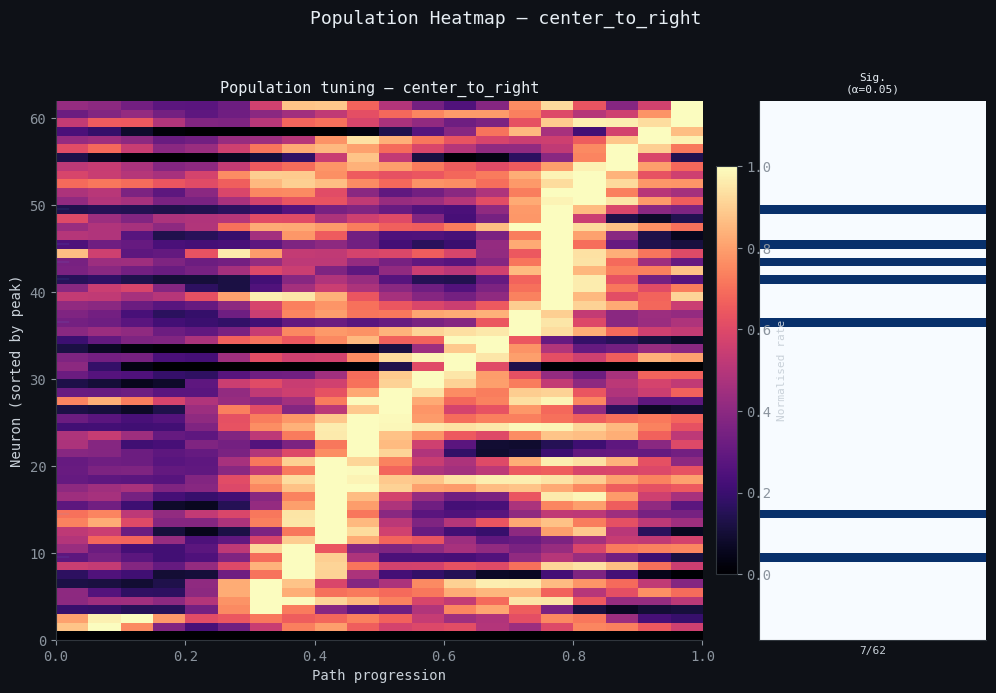

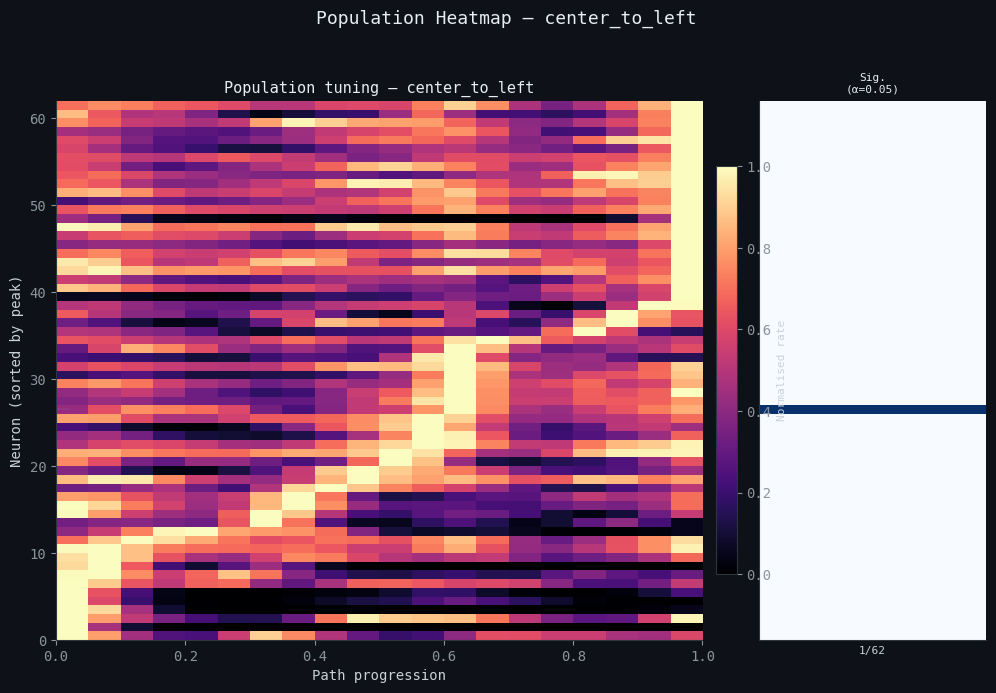

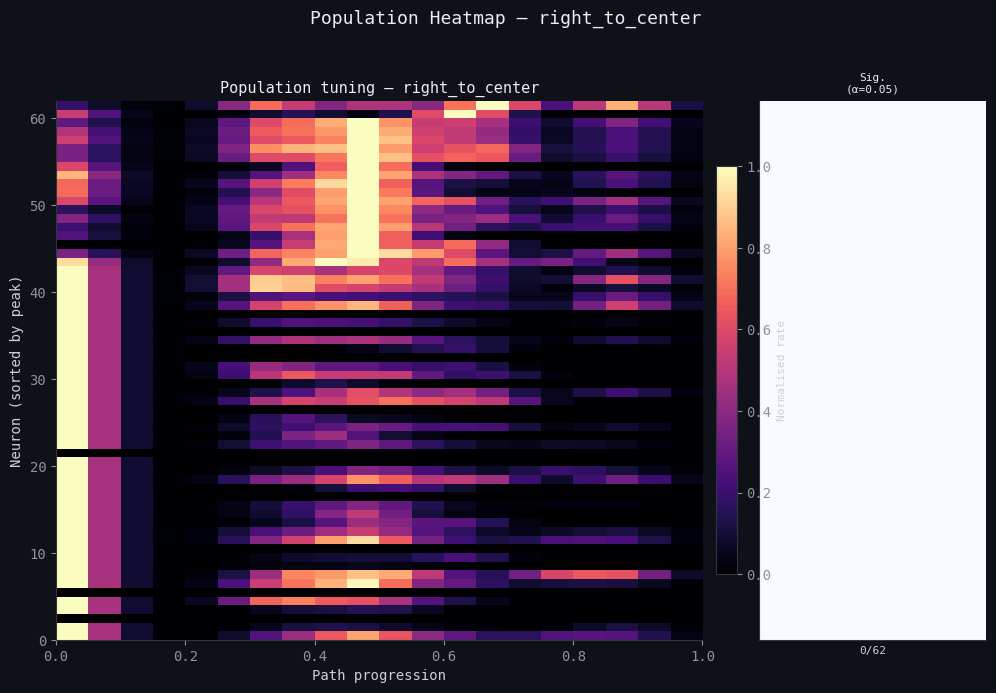

In [ ]:
# Cell 6 — population heatmap, one figure per trajectory
for traj in trajectories:
    norm_rates     = norm_rates_by_traj[traj]
    sort_order     = sort_order_by_traj[traj]
    is_significant = is_significant_by_traj[traj]
    n_sig          = int(is_significant.sum())
    sorted_norm    = norm_rates[sort_order]
    sig_sorted     = is_significant[sort_order]

    fig, axes = plt.subplots(1, 2, figsize=(12, 7),
                             gridspec_kw={"width_ratios": [3, 1], "wspace": 0.05},
                             facecolor="#0e1117")
    im = axes[0].imshow(sorted_norm, aspect="auto", origin="lower", cmap="magma",
                        norm=Normalize(vmin=0, vmax=1),
                        extent=[0, 1, 0, n_neurons], interpolation="nearest")
    axes[0].set_xlabel("Path progression", fontsize=10)
    axes[0].set_ylabel("Neuron (sorted by peak)", fontsize=10)
    axes[0].set_title(f"Population tuning — {traj}", fontsize=11)
    for y_idx, sig in enumerate(sig_sorted):
        if sig:
            axes[0].axhline(y_idx + 0.5, color=SIG_COLOR, lw=0.3,
                            alpha=0.4, xmin=0, xmax=0.02)
    cbar = fig.colorbar(im, ax=axes[0], fraction=0.03, pad=0.02)
    cbar.set_label("Normalised rate", fontsize=8)
    axes[1].imshow(sig_sorted.astype(float).reshape(-1, 1), aspect="auto",
                   origin="lower", cmap="Blues", vmin=0, vmax=1,
                   extent=[0, 1, 0, n_neurons], interpolation="nearest")
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    axes[1].set_title(f"Sig.\n(α={ALPHA})", fontsize=8)
    axes[1].set_xlabel(f"{n_sig}/{n_neurons}", fontsize=8)
    fig.suptitle(f"Population Heatmap — {traj}", fontsize=13,
                 color="#e6edf3", y=1.01)
    plt.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/population_heatmap_{traj}.png", dpi=150,
                bbox_inches="tight", facecolor="#0e1117")
    plt.show()
plt.show()

Computing tuning curves for 62 neurons ...
Running 500 shuffles per neuron ...
0/62 neurons significantly tuned (α=0.05)

Sanity check: first few spike arrays
neuron 0: shape=(73517,), first_spikes=[1.76539079e+09 1.76539079e+09 1.76539079e+09 1.76539079e+09
 1.76539079e+09]
neuron 1: shape=(36406,), first_spikes=[1.76539079e+09 1.76539079e+09 1.76539079e+09 1.76539079e+09
 1.76539079e+09]
neuron 2: shape=(9138,), first_spikes=[1.76539079e+09 1.76539080e+09 1.76539080e+09 1.76539080e+09
 1.76539080e+09]
neuron 3: shape=(6072,), first_spikes=[1.76539084e+09 1.76539085e+09 1.76539086e+09 1.76539087e+09
 1.76539087e+09]
neuron 4: shape=(2825,), first_spikes=[1.76539189e+09 1.76539199e+09 1.76539200e+09 1.76539200e+09
 1.76539200e+09]

Sanity check: identical spike arrays
cell 0 identical to cell 1: False
cell 0 identical to cell 2: False
cell 0 identical to cell 3: False
cell 0 identical to cell 4: False


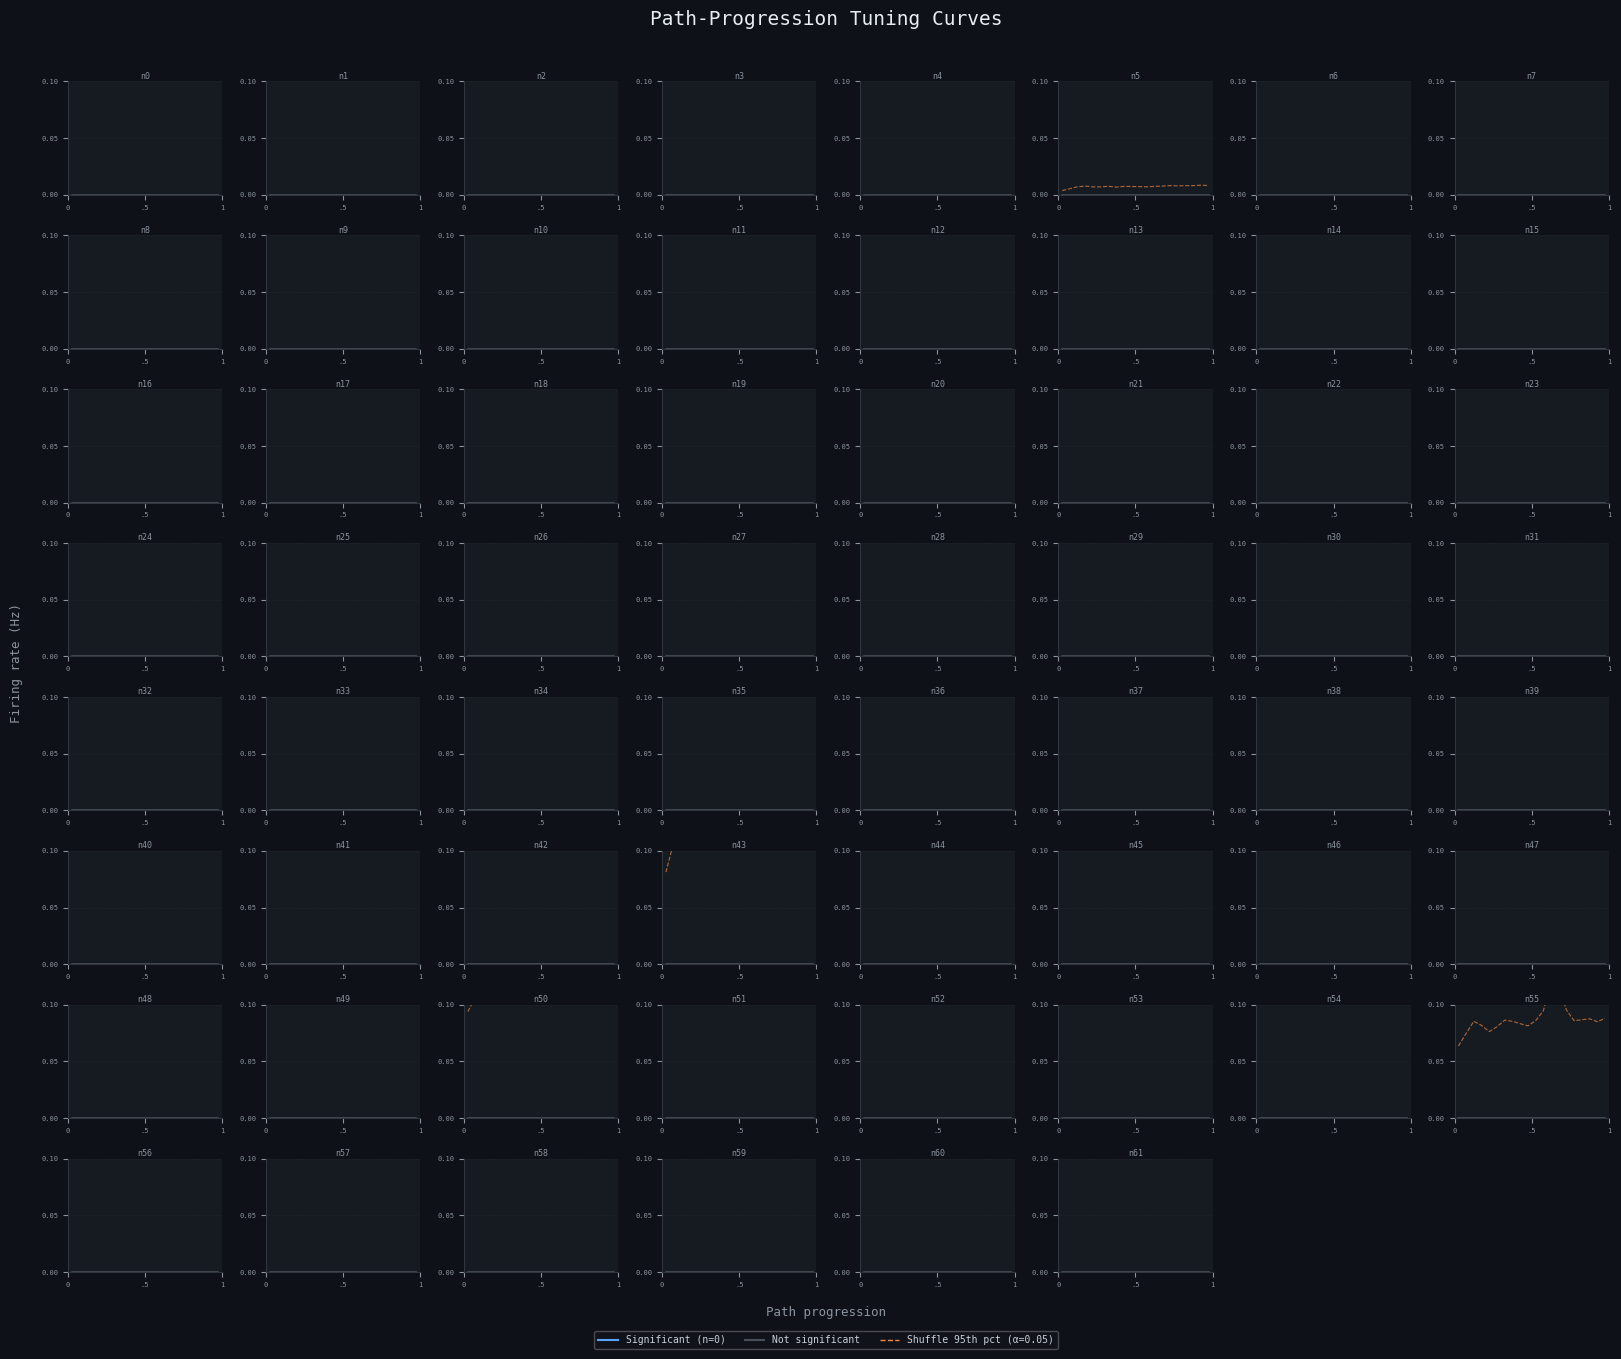

/tmp/ipykernel_930154/98846537.py:571: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


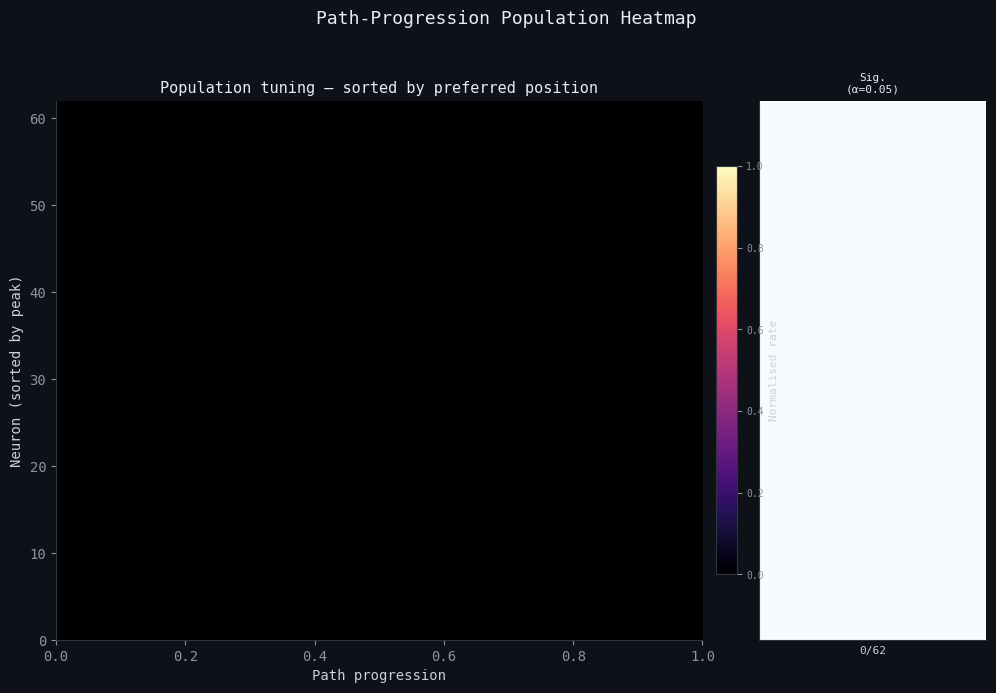

IndexError: list index out of range

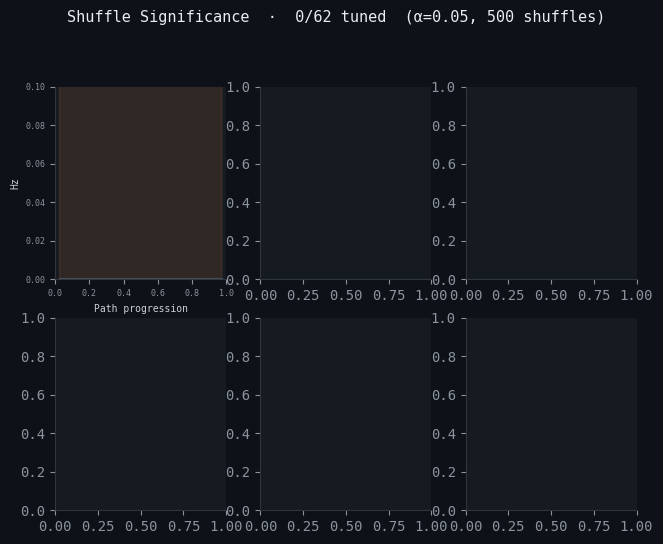

In [ ]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d

N_BINS = 20
SMOOTH_SIGMA = 1.0
MIN_OCCUPANCY_S = 0.05
N_SHUFFLES = 500
ALPHA = 0.05
SPEED_THRESHOLD = None
OUTPUT_DIR = "."

# EDIT: If your path_df has discontinuous path traversals, this prevents interpolation
# across large behavioral gaps. If None, it is inferred as 5 * median dt.
MAX_TIME_GAP_S = None


def get_contiguous_segments(
    times: np.ndarray,
    max_time_gap_s: float | None = None,
) -> list[slice]:
    """Find contiguous behavioral segments.

    Parameters
    ----------
    times : np.ndarray
        Time values with shape ``(n_time,)``.
    max_time_gap_s : float | None, default=None
        Maximum allowed gap between adjacent time samples. If None, use
        ``5 * median(diff(times))``.

    Returns
    -------
    segments : list[slice]
        List of slices defining contiguous time segments.
    """
    times = np.asarray(times, dtype=float)

    if times.size < 2:
        return [slice(0, times.size)]

    dt = np.diff(times)
    if max_time_gap_s is None:
        max_time_gap_s = 5.0 * float(np.nanmedian(dt))

    break_points = np.flatnonzero(dt > max_time_gap_s) + 1
    segment_starts = np.r_[0, break_points]
    segment_stops = np.r_[break_points, times.size]

    return [
        slice(start, stop)
        for start, stop in zip(segment_starts, segment_stops)
        if stop - start >= 2
    ]


def compute_tuning_curve(
    spike_times: np.ndarray,
    path_times: np.ndarray,
    path_values: np.ndarray,
    bins: np.ndarray,
    min_occupancy_s: float = MIN_OCCUPANCY_S,
    smooth_sigma: float = SMOOTH_SIGMA,
    max_time_gap_s: float | None = MAX_TIME_GAP_S,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute path-progression tuning curve for one neuron.

    Parameters
    ----------
    spike_times : np.ndarray
        Spike times for one neuron, with shape ``(n_spikes,)``.
    path_times : np.ndarray
        Behavioral timestamps, with shape ``(n_time,)``.
    path_values : np.ndarray
        Path-progression values aligned to ``path_times``, with shape
        ``(n_time,)``.
    bins : np.ndarray
        Path-progression bin edges, with shape ``(n_bins + 1,)``.
    min_occupancy_s : float, default=MIN_OCCUPANCY_S
        Minimum occupancy in seconds required for a bin to be valid.
    smooth_sigma : float, default=SMOOTH_SIGMA
        Gaussian smoothing sigma in bin units.
    max_time_gap_s : float | None, default=MAX_TIME_GAP_S
        Maximum allowed gap between adjacent behavioral time samples.
        This prevents interpolation across discontinuous path traversals.

    Returns
    -------
    rate : np.ndarray
        Firing rate in Hz, with shape ``(n_bins,)``.
    occupancy : np.ndarray
        Occupancy in seconds, with shape ``(n_bins,)``.
    """
    spike_times = np.asarray(spike_times, dtype=float)
    path_times = np.asarray(path_times, dtype=float)
    path_values = np.asarray(path_values, dtype=float)

    n_bins = len(bins) - 1

    finite_path_mask = np.isfinite(path_times) & np.isfinite(path_values)
    path_times = path_times[finite_path_mask]
    path_values = path_values[finite_path_mask]

    sort_order = np.argsort(path_times)
    path_times = path_times[sort_order]
    path_values = path_values[sort_order]

    occupancy = np.zeros(n_bins, dtype=float)
    counts = np.zeros(n_bins, dtype=float)

    segments = get_contiguous_segments(
        times=path_times,
        max_time_gap_s=max_time_gap_s,
    )

    for segment in segments:
        segment_times = path_times[segment]
        segment_values = path_values[segment]

        if segment_times.size < 2:
            continue

        dt = float(np.nanmedian(np.diff(segment_times)))

        bin_idx = np.clip(
            np.digitize(segment_values, bins) - 1,
            0,
            n_bins - 1,
        )
        occupancy += np.bincount(bin_idx, minlength=n_bins) * dt

        # EDIT: Only use spikes inside this actual behavioral segment.
        in_segment = (
            (spike_times >= segment_times[0])
            & (spike_times <= segment_times[-1])
        )
        segment_spike_times = spike_times[in_segment]

        if segment_spike_times.size == 0:
            continue

        # EDIT: left/right NaN prevents endpoint clamping by np.interp.
        spike_pos = np.interp(
            segment_spike_times,
            segment_times,
            segment_values,
            left=np.nan,
            right=np.nan,
        )

        valid_spike_pos = (
            np.isfinite(spike_pos)
            & (spike_pos >= bins[0])
            & (spike_pos <= bins[-1])
        )
        spike_pos = spike_pos[valid_spike_pos]

        segment_counts, _ = np.histogram(spike_pos, bins=bins)
        counts += segment_counts

    rate = np.full(n_bins, np.nan)
    valid = occupancy > min_occupancy_s
    rate[valid] = counts[valid] / occupancy[valid]

    if smooth_sigma > 0:
        filled = np.where(valid, rate, 0.0)
        smoothed = gaussian_filter1d(filled, sigma=smooth_sigma)

        valid_smoothed = gaussian_filter1d(valid.astype(float), sigma=smooth_sigma)
        with np.errstate(invalid="ignore", divide="ignore"):
            smoothed = np.where(
                valid_smoothed > 0.01,
                smoothed / valid_smoothed,
                np.nan,
            )

        rate = np.where(valid, smoothed, np.nan)

    return rate, occupancy


def run_shuffle_test(
    spike_times: np.ndarray,
    path_times: np.ndarray,
    path_values: np.ndarray,
    bins: np.ndarray,
    n_shuffles: int = N_SHUFFLES,
    max_time_gap_s: float | None = MAX_TIME_GAP_S,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute circular-shift shuffle null distribution.

    Parameters
    ----------
    spike_times : np.ndarray
        Spike times for one neuron, with shape ``(n_spikes,)``.
    path_times : np.ndarray
        Behavioral timestamps, with shape ``(n_time,)``.
    path_values : np.ndarray
        Path-progression values aligned to ``path_times``, with shape
        ``(n_time,)``.
    bins : np.ndarray
        Path-progression bin edges, with shape ``(n_bins + 1,)``.
    n_shuffles : int, default=N_SHUFFLES
        Number of circular shuffles.
    max_time_gap_s : float | None, default=MAX_TIME_GAP_S
        Maximum allowed gap between adjacent behavioral samples.

    Returns
    -------
    p95_per_bin : np.ndarray
        Per-bin shuffle threshold, with shape ``(n_bins,)``.
    mean_per_bin : np.ndarray
        Per-bin shuffle mean, with shape ``(n_bins,)``.
    """
    path_times = np.asarray(path_times, dtype=float)
    spike_times = np.asarray(spike_times, dtype=float)

    t_start = float(path_times[0])
    t_stop = float(path_times[-1])
    total_duration = t_stop - t_start

    shuffle_rates = np.full((n_shuffles, len(bins) - 1), np.nan)

    for i_shuffle in range(n_shuffles):
        # EDIT: Keep the original absolute time origin.
        shift = np.random.uniform(20.0, total_duration - 20.0)
        shuffled = ((spike_times - t_start + shift) % total_duration) + t_start

        rate, _ = compute_tuning_curve(
            spike_times=shuffled,
            path_times=path_times,
            path_values=path_values,
            bins=bins,
            max_time_gap_s=max_time_gap_s,
        )
        shuffle_rates[i_shuffle] = rate

    return (
        np.nanpercentile(shuffle_rates, 100 * (1 - ALPHA), axis=0),
        np.nanmean(shuffle_rates, axis=0),
    )


def safe_row_normalize(rates: np.ndarray) -> np.ndarray:
    """Normalize each row to its maximum finite value.

    Parameters
    ----------
    rates : np.ndarray
        Tuning curves with shape ``(n_neurons, n_bins)``.

    Returns
    -------
    norm_rates : np.ndarray
        Row-normalized tuning curves with shape ``(n_neurons, n_bins)``.
    """
    rates = np.asarray(rates, dtype=float)

    row_max = np.nanmax(rates, axis=1, keepdims=True)
    row_max = np.where(np.isfinite(row_max) & (row_max > 0), row_max, 1.0)

    return rates / row_max


# ── Compute tuning curves ────────────────────────────────────────────────────

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

path_times_arr = path_df.index.to_numpy(dtype=float)
path_values_arr = path_df["path_progression"].to_numpy(dtype=float)

finite_path_mask = np.isfinite(path_times_arr) & np.isfinite(path_values_arr)
path_times_arr = path_times_arr[finite_path_mask]
path_values_arr = path_values_arr[finite_path_mask]

sort_order_path = np.argsort(path_times_arr)
path_times_arr = path_times_arr[sort_order_path]
path_values_arr = path_values_arr[sort_order_path]

bins = np.linspace(0, 1, N_BINS + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
n_neurons = len(spike_times)

all_rates = np.full((n_neurons, N_BINS), np.nan)
all_occupancy = np.full((n_neurons, N_BINS), np.nan)

print(f"Computing tuning curves for {n_neurons} neurons ...")

for i_neuron, spk in enumerate(spike_times):
    all_rates[i_neuron], all_occupancy[i_neuron] = compute_tuning_curve(
        spike_times=np.asarray(spk, dtype=float),
        path_times=path_times_arr,
        path_values=path_values_arr,
        bins=bins,
    )

# Normalize rows to [0, 1] for heatmap; find peak bin per neuron.
norm_rates = safe_row_normalize(all_rates)

# EDIT: Avoid nanargmax crashing or behaving unexpectedly for all-NaN rows.
has_valid_rate = np.any(np.isfinite(norm_rates), axis=1)
peak_bin = np.zeros(n_neurons, dtype=int)
peak_bin[has_valid_rate] = np.nanargmax(norm_rates[has_valid_rate], axis=1)

sort_order = np.lexsort((np.arange(n_neurons), peak_bin))


# ── Shuffle significance ─────────────────────────────────────────────────────

print(f"Running {N_SHUFFLES} shuffles per neuron ...")

is_significant = np.zeros(n_neurons, dtype=bool)
shuffle_p95_all = np.full((n_neurons, N_BINS), np.nan)

for i_neuron, spk in enumerate(spike_times):
    spk = np.asarray(spk, dtype=float)

    if spk.size < 10 or not has_valid_rate[i_neuron]:
        continue

    p95, _ = run_shuffle_test(
        spike_times=spk,
        path_times=path_times_arr,
        path_values=path_values_arr,
        bins=bins,
    )
    shuffle_p95_all[i_neuron] = p95

    peak = int(peak_bin[i_neuron])
    if np.isfinite(all_rates[i_neuron, peak]) and np.isfinite(p95[peak]):
        is_significant[i_neuron] = all_rates[i_neuron, peak] > p95[peak]

n_sig = int(is_significant.sum())
print(f"{n_sig}/{n_neurons} neurons significantly tuned (α={ALPHA})")


# ── Sanity checks ─────────────────────────────────────────────────────────────

print("\nSanity check: first few spike arrays")
for i_neuron in range(min(5, n_neurons)):
    spk = np.asarray(spike_times[i_neuron], dtype=float)
    print(f"neuron {i_neuron}: shape={spk.shape}, first_spikes={spk[:5]}")

print("\nSanity check: identical spike arrays")
for i_neuron in range(1, min(5, n_neurons)):
    print(
        f"cell 0 identical to cell {i_neuron}: "
        f"{np.array_equal(np.asarray(spike_times[0]), np.asarray(spike_times[i_neuron]))}"
    )


# ── Style ────────────────────────────────────────────────────────────────────

plt.rcParams.update(
    {
        "figure.facecolor": "#0e1117",
        "axes.facecolor": "#161b22",
        "axes.edgecolor": "#30363d",
        "axes.labelcolor": "#c9d1d9",
        "axes.titlecolor": "#e6edf3",
        "xtick.color": "#8b949e",
        "ytick.color": "#8b949e",
        "text.color": "#c9d1d9",
        "grid.color": "#21262d",
        "grid.linestyle": "--",
        "grid.linewidth": 0.5,
        "font.family": "monospace",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

SIG_COLOR = "#58a6ff"
INSIG_COLOR = "#484f58"
SHUF_COLOR = "#f0883e"


# ── Plot: per-neuron tuning curve grid ───────────────────────────────────────

n_cols = 8
n_rows = int(np.ceil(n_neurons / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(n_cols * 2.0, n_rows * 1.6),
    facecolor="#0e1117",
    squeeze=False,
)

fig.suptitle(
    "Path-Progression Tuning Curves",
    fontsize=14,
    color="#e6edf3",
    y=1.01,
)

for idx in range(n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col]

    if idx >= n_neurons:
        ax.set_visible(False)
        continue

    rate = all_rates[idx]
    p95 = shuffle_p95_all[idx]
    sig = is_significant[idx]
    color = SIG_COLOR if sig else INSIG_COLOR

    ax.fill_between(bin_centers, np.nan_to_num(rate), alpha=0.25, color=color)
    ax.plot(bin_centers, rate, color=color, lw=1.2)

    if not np.all(np.isnan(p95)):
        ax.plot(
            bin_centers,
            p95,
            color=SHUF_COLOR,
            lw=0.8,
            linestyle="--",
            alpha=0.7,
        )

    peak = np.nanmax(rate) if not np.all(np.isnan(rate)) else 0
    ax.set_ylim(0, max(peak * 1.2, 0.1))
    ax.set_xlim(0, 1)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(["0", ".5", "1"], fontsize=5)
    ax.tick_params(axis="y", labelsize=5)
    ax.set_title(
        f"n{idx}",
        fontsize=6,
        pad=2,
        color=SIG_COLOR if sig else "#8b949e",
    )
    ax.yaxis.set_major_locator(plt.MaxNLocator(2))
    ax.grid(True, axis="y", linewidth=0.4)

fig.text(
    0.5,
    -0.01,
    "Path progression",
    ha="center",
    fontsize=9,
    color="#8b949e",
)
fig.text(
    -0.01,
    0.5,
    "Firing rate (Hz)",
    va="center",
    rotation="vertical",
    fontsize=9,
    color="#8b949e",
)

fig.legend(
    handles=[
        Line2D(
            [0],
            [0],
            color=SIG_COLOR,
            lw=1.5,
            label=f"Significant (n={n_sig})",
        ),
        Line2D(
            [0],
            [0],
            color=INSIG_COLOR,
            lw=1.5,
            label="Not significant",
        ),
        Line2D(
            [0],
            [0],
            color=SHUF_COLOR,
            lw=1.0,
            linestyle="--",
            label=f"Shuffle 95th pct (α={ALPHA})",
        ),
    ],
    loc="lower center",
    ncol=3,
    fontsize=7,
    framealpha=0.3,
    bbox_to_anchor=(0.5, -0.04),
)

plt.tight_layout()
fig.savefig(
    output_dir / "tuning_curves_grid.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="#0e1117",
)
plt.show()


# ── Plot: population heatmap ─────────────────────────────────────────────────

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 7),
    gridspec_kw={"width_ratios": [3, 1], "wspace": 0.05},
    facecolor="#0e1117",
)

sorted_norm = norm_rates[sort_order]

im = axes[0].imshow(
    sorted_norm,
    aspect="auto",
    origin="lower",
    cmap="magma",
    norm=Normalize(vmin=0, vmax=1),
    extent=[0, 1, 0, n_neurons],
    interpolation="nearest",
)

axes[0].set_xlabel("Path progression", fontsize=10)
axes[0].set_ylabel("Neuron (sorted by peak)", fontsize=10)
axes[0].set_title("Population tuning — sorted by preferred position", fontsize=11)

sig_sorted = is_significant[sort_order]
for y_idx, sig in enumerate(sig_sorted):
    if sig:
        axes[0].axhline(
            y_idx + 0.5,
            color=SIG_COLOR,
            lw=0.3,
            alpha=0.4,
            xmin=0,
            xmax=0.02,
        )

cbar = fig.colorbar(im, ax=axes[0], fraction=0.03, pad=0.02)
cbar.set_label("Normalised rate", fontsize=8)
cbar.ax.tick_params(labelsize=7)

axes[1].imshow(
    sig_sorted.astype(float).reshape(-1, 1),
    aspect="auto",
    origin="lower",
    cmap="Blues",
    vmin=0,
    vmax=1,
    extent=[0, 1, 0, n_neurons],
    interpolation="nearest",
)

axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].set_title(f"Sig.\n(α={ALPHA})", fontsize=8)
axes[1].set_xlabel(f"{n_sig}/{n_neurons}", fontsize=8)

fig.suptitle(
    "Path-Progression Population Heatmap",
    fontsize=13,
    color="#e6edf3",
    y=1.01,
)

plt.tight_layout()
fig.savefig(
    output_dir / "population_heatmap.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="#0e1117",
)
plt.show()


# ── Plot: shuffle significance examples ──────────────────────────────────────

sig_indices = np.where(is_significant)[0]
insig_indices = np.where(~is_significant & has_valid_rate)[0]

if sig_indices.size > 0:
    margins = np.array(
        [
            np.nanmax(all_rates[i]) - np.nanmax(shuffle_p95_all[i])
            if not np.all(np.isnan(shuffle_p95_all[i]))
            else -np.inf
            for i in sig_indices
        ]
    )
    top_sig = sig_indices[np.argsort(-margins)[:6]]
else:
    top_sig = np.array([], dtype=int)

if insig_indices.size > 0:
    insig_peak_rates = np.array(
        [
            np.nanmax(all_rates[i]) if not np.all(np.isnan(all_rates[i])) else -np.inf
            for i in insig_indices
        ]
    )
    top_insig = insig_indices[np.argsort(-insig_peak_rates)[:6]]
else:
    top_insig = np.array([], dtype=int)

example_neurons = np.concatenate([top_sig, top_insig]).astype(int)
n_examples = len(example_neurons)

if n_examples > 0:
    n_cols_ex = max(int(np.ceil(n_examples / 2)), 1)

    fig, axes = plt.subplots(
        2,
        n_cols_ex,
        figsize=(n_cols_ex * 2.5, 5.5),
        facecolor="#0e1117",
        sharey=False,
        squeeze=False,
    )

    fig.suptitle(
        (
            f"Shuffle Significance  ·  {n_sig}/{n_neurons} tuned  "
            f"(α={ALPHA}, {N_SHUFFLES} shuffles)"
        ),
        fontsize=11,
        color="#e6edf3",
        y=1.02,
    )

    for plot_idx, neuron_idx in enumerate(example_neurons):
        row = plot_idx // n_cols_ex
        col = plot_idx % n_cols_ex
        ax = axes[row, col]

        rate = all_rates[neuron_idx]
        p95 = shuffle_p95_all[neuron_idx]
        sig = is_significant[neuron_idx]
        color = SIG_COLOR if sig else INSIG_COLOR

        ax.fill_between(bin_centers, np.nan_to_num(rate), alpha=0.2, color=color)
        ax.plot(bin_centers, rate, color=color, lw=1.5)

        if not np.all(np.isnan(p95)):
            ax.fill_between(
                bin_centers,
                np.nan_to_num(p95),
                alpha=0.12,
                color=SHUF_COLOR,
            )
            ax.plot(
                bin_centers,
                p95,
                color=SHUF_COLOR,
                lw=1.0,
                linestyle="--",
                alpha=0.9,
            )

        peak = np.nanmax(rate) if not np.all(np.isnan(rate)) else 0
        ax.set_ylim(0, max(peak * 1.25, 0.1))
        ax.set_xlim(0, 1)
        ax.set_xlabel("Path progression", fontsize=7)
        ax.set_ylabel("Hz", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.set_title(
        f"{unit_ids[idx]}",
        fontsize=6,
        pad=2,
        color=SIG_COLOR if sig else "#8b949e",
    )
        ax.grid(True, axis="y", linewidth=0.4)

    for plot_idx in range(n_examples, axes.size):
        axes[plot_idx // n_cols_ex, plot_idx % n_cols_ex].set_visible(False)

    fig.legend(
        handles=[
            Line2D(
                [0],
                [0],
                color=SIG_COLOR,
                lw=1.5,
                label="Observed rate",
            ),
            Line2D(
                [0],
                [0],
                color=SHUF_COLOR,
                lw=1.0,
                linestyle="--",
                label="Shuffle 95th pct",
            ),
        ],
        loc="lower center",
        ncol=2,
        fontsize=8,
        framealpha=0.3,
        bbox_to_anchor=(0.5, -0.03),
    )

    plt.tight_layout()
    fig.savefig(
        output_dir / "shuffle_significance.png",
        dpi=150,
        bbox_inches="tight",
        facecolor="#0e1117",
    )
    plt.show()
else:
    print("No valid example neurons to plot.")

In [70]:
len(spike_times)

62

In [71]:
spike_times

[array([1.76539079e+09, 1.76539079e+09, 1.76539079e+09, ...,
        1.76541239e+09, 1.76541239e+09, 1.76541239e+09]),
 array([1.76539079e+09, 1.76539079e+09, 1.76539079e+09, ...,
        1.76541239e+09, 1.76541239e+09, 1.76541239e+09]),
 array([1.76539079e+09, 1.76539080e+09, 1.76539080e+09, ...,
        1.76541239e+09, 1.76541239e+09, 1.76541239e+09]),
 array([1.76539084e+09, 1.76539085e+09, 1.76539086e+09, ...,
        1.76541231e+09, 1.76541232e+09, 1.76541233e+09]),
 array([1.76539189e+09, 1.76539199e+09, 1.76539200e+09, ...,
        1.76541168e+09, 1.76541168e+09, 1.76541168e+09]),
 array([1.76539229e+09, 1.76539231e+09, 1.76539231e+09, 1.76539231e+09,
        1.76539239e+09, 1.76539239e+09, 1.76539243e+09, 1.76539244e+09,
        1.76539245e+09, 1.76539247e+09, 1.76539247e+09, 1.76539249e+09,
        1.76539253e+09, 1.76539254e+09, 1.76539421e+09, 1.76539481e+09,
        1.76539486e+09, 1.76539486e+09, 1.76539487e+09, 1.76539612e+09,
        1.76539759e+09, 1.76539759e+09, 1.765

In [32]:
import pynapple as nap
import numpy as np

# Convert ms → seconds, zero-anchored
t0 = min(arr[0] for arr in spike_times)  # global start time

tsgroup = nap.TsGroup({
    i: nap.Ts(t=(arr - t0))
    for i, arr in enumerate(spike_times)
})
# Same offset and scale applied to your time column
feature = nap.Tsd(
    t=(path_df["time"].values - t0),
    d=path_df["path_progression"].values
)

In [33]:
path_df

,time,linear_position,track_segment_id,projected_x_position,projected_y_position,trajectory,trajectory_progress,path_progression
0,1.765393e+09,116.178469,1,108.677648,75.258329,NaN,NaN,NaN
1,1.765393e+09,115.986569,1,108.845151,75.164690,NaN,NaN,NaN
2,1.765393e+09,115.693713,1,109.100776,75.021788,NaN,NaN,NaN
3,1.765393e+09,115.238527,1,109.498093,74.799677,NaN,NaN,NaN
4,1.765393e+09,114.848941,1,109.838150,74.609576,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
29403,1.765394e+09,45.515805,0,145.897778,88.266515,left_to_center,0.240092,0.240092
29404,1.765394e+09,47.048462,0,145.150161,86.928567,left_to_center,0.253431,0.253431
29405,1.765394e+09,48.494746,0,144.444676,85.666018,left_to_center,0.266769,0.266769
29406,1.765394e+09,49.612224,0,143.899580,84.690505,left_to_center,0.266769,0.266769


In [34]:
print(f"Spike time range (s): {tsgroup[0].index.min():.1f} – {tsgroup[0].index.max():.1f}")
print(f"Feature time range (s): {feature.index.min():.1f} – {feature.index.max():.1f}")
# These should overlap substantially — if one is empty or way off, your t0/units are mismatched

Spike time range (s): 0.0 – 21603.8
Feature time range (s): 2472.4 – 3673.1


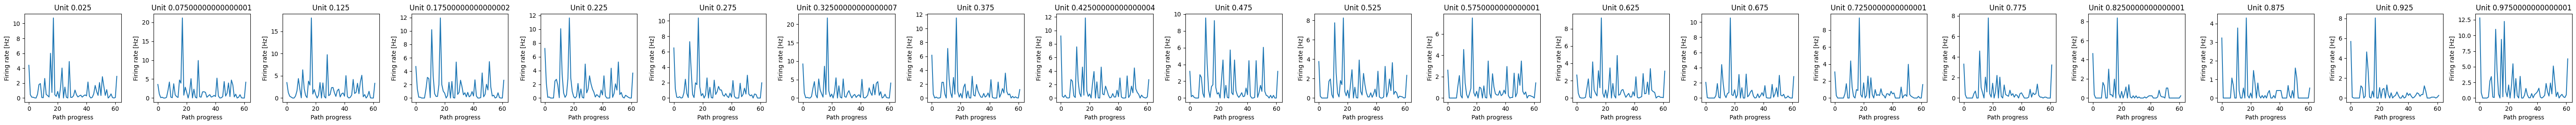

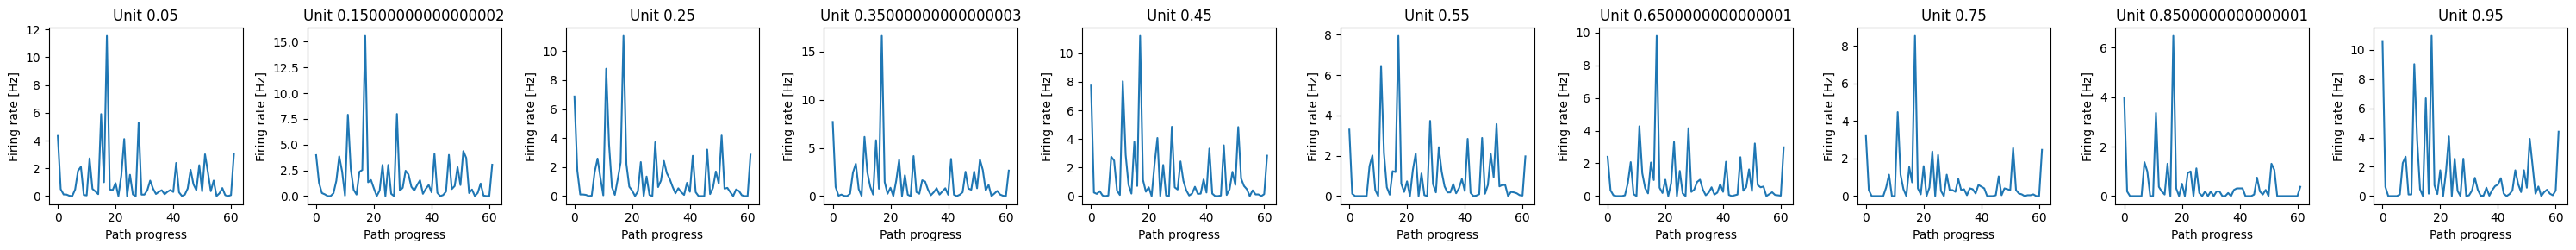

In [39]:
tuning_curves = nap.compute_tuning_curves(
    data=tsgroup,
    features=feature,
    bins=10,
    range=(path_df["path_progression"].min(), path_df["path_progression"].max()),
)

import matplotlib.pyplot as plt

tc_df = tuning_curves.to_pandas()  # rows = bins, columns = unit indices

fig, axes = plt.subplots(1, len(tc_df.columns), figsize=(3 * len(tc_df.columns), 3))
if len(tc_df.columns) == 1:
    axes = [axes]

for i, col in enumerate(tc_df.columns):
    axes[i].plot(tc_df.index, tc_df[col])
    axes[i].set_title(f"Unit {col}")
    axes[i].set_xlabel("Path progress")
    axes[i].set_ylabel("Firing rate [Hz]")

plt.tight_layout()
plt.show()

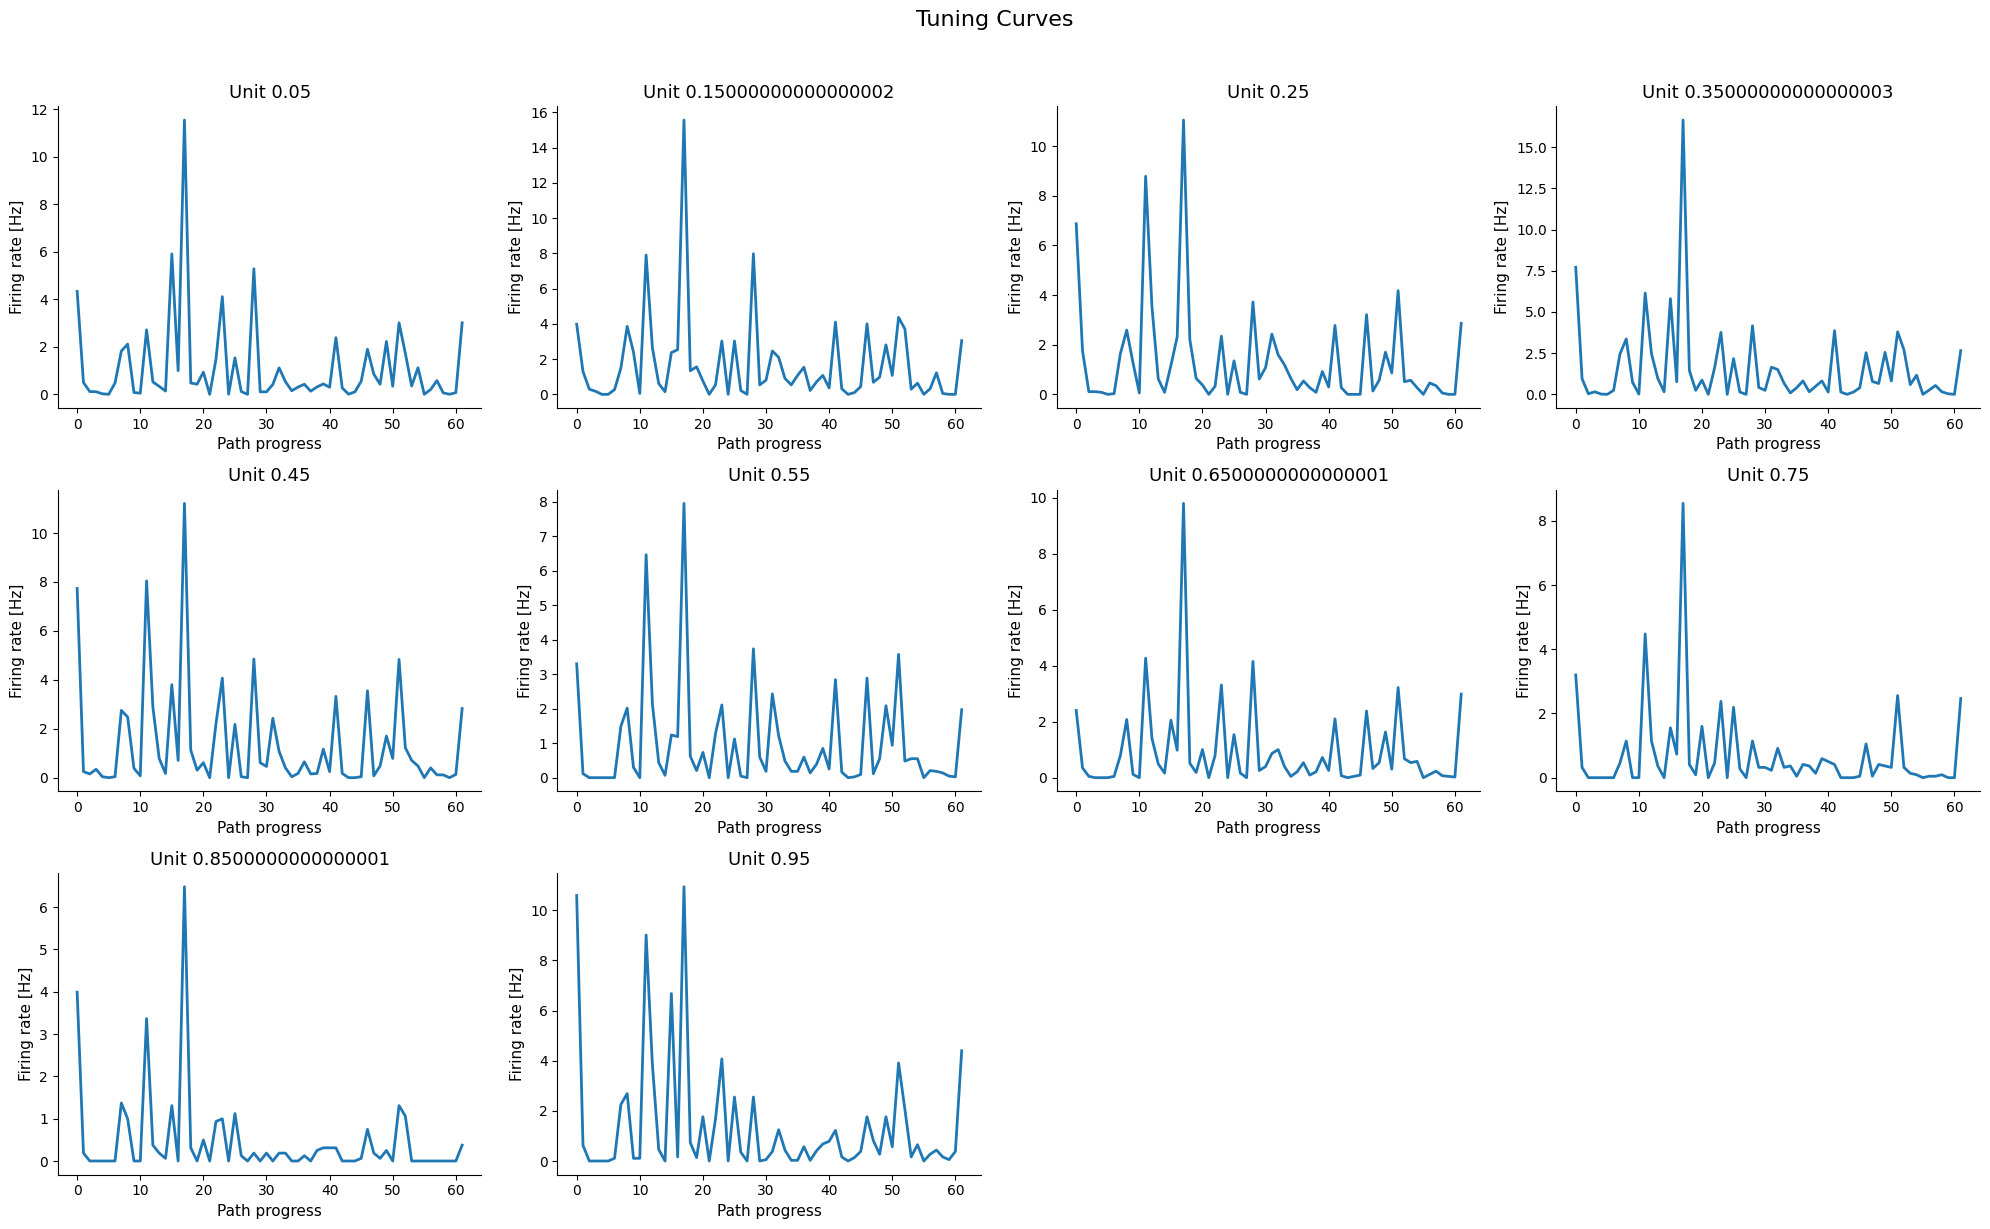

In [40]:
tc_df = tuning_curves.to_pandas()  # rows = bins, columns = unit indices

n_units = len(tc_df.columns)
ncols = 4
nrows = (n_units + ncols - 1) // ncols  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(tc_df.columns):
    axes[i].plot(tc_df.index, tc_df[col], linewidth=2)
    axes[i].set_title(f"Unit {col}", fontsize=13)
    axes[i].set_xlabel("Path progress", fontsize=11)
    axes[i].set_ylabel("Firing rate [Hz]", fontsize=11)
    axes[i].spines[["top", "right"]].set_visible(False)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Tuning Curves", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()